In [ ]:
import os
import numpy as np
import pandas as pd
import scipy.optimize as optimize
import matplotlib.pyplot as plt
%matplotlib inline  
import locale
locale.setlocale(locale.LC_TIME, "pt_PT") # processar datas em PT
import aosol.series.consumo as series
import aosol.series.producao as seriesprod
import aosol.series.pvgis as pvgis
import aosol.series.precos as precos
import aosol.analise.analise_energia as ae
import aosol.analise.analise_financeira as af
import aosol.analise.analise_precos_energia as ape
import aosol.analise.optimiza_upac as optimiza
from aosol.armazenamento.bateria import bateria
from tabulate import tabulate

# Optimzação de UPAC - Lisboa

Qual a dimensão de uma UPAC sem e com bateria que minimiza o custo de energia?
* Na zona de Lisboa
* Para os diferentes tarifários: simples, bihorario, indexado
* Para diferentes custos de instalação PV (€/kWp) e Bateria (€/kWh)
* Com e sem venda à rede

Pressupostos:
* Consumo anual 3600 kWh (300 kWh/mes)
* Tamanhos de UPAC normalizados ao consumo anual.
* Perfil de consumo médio da E-REDES 2025
* Despacho da bateria simples: utiliza energia quando está disponivel
* Dados de produção do PVGIS

$r_{pv} = \frac{Producao_{PV}}{Consumo} \left[ \frac{kWh}{kWh} \right]$

$r_{bat} = \frac{CAP_{bat}}{Consumo} \left[ \frac{kWh}{MWh} \right]$

Custos Energia:
* Simples : 0.1453 €/kWh (EDP)
* Bihorario Vazio : 0.1025 €/kWh (Gold Energy)
* Bihorario Fora Vazio : 0.1984 €/kWh (Gold Energy)

Preço venda à rede : 0.03 €/kWh (Meo energy)

## Consumo

In [2]:
# =====================
# Consumo
# =====================
ano_consumo = 2025
perfil = 'BTN C' # ver na document
consumo_anual = 3600 # 300 kWh/mes
fich_perfil_eredes = r"./consumo/perfis_eredes/Perfil_Consumo_Injeção_E-REDES_2025.csv"

In [3]:
perfil_eredes = series.leitura_perfis_eredes(fich_perfil_eredes, perfil)
consumo_medio = series.ajustar_perfil_eredes_a_consumo_anual(perfil_eredes, consumo_anual, 'BTN C', 'consumo', resample_horario=False)

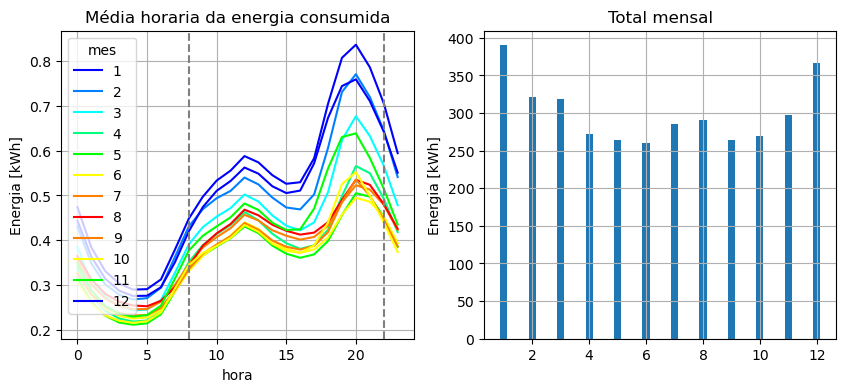

In [4]:
ae.plot_perfil_12x24_e_mensal(consumo_medio, 'consumo', quartohorario=True)

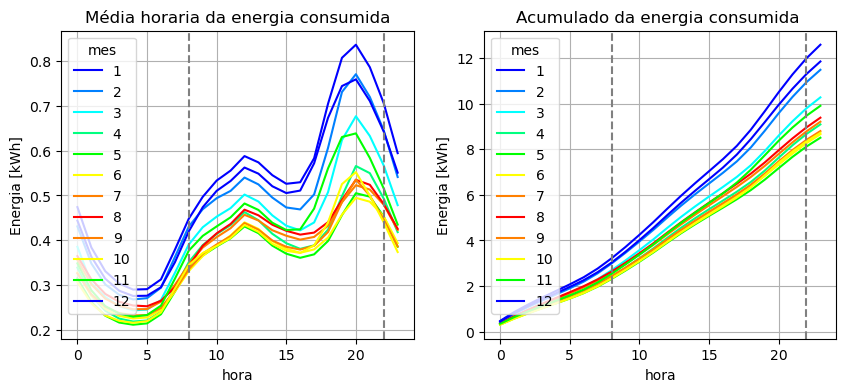

In [5]:
ae.plot_perfil_12x24_medio_e_acumulado(consumo_medio, 'consumo', quartohorario=True)

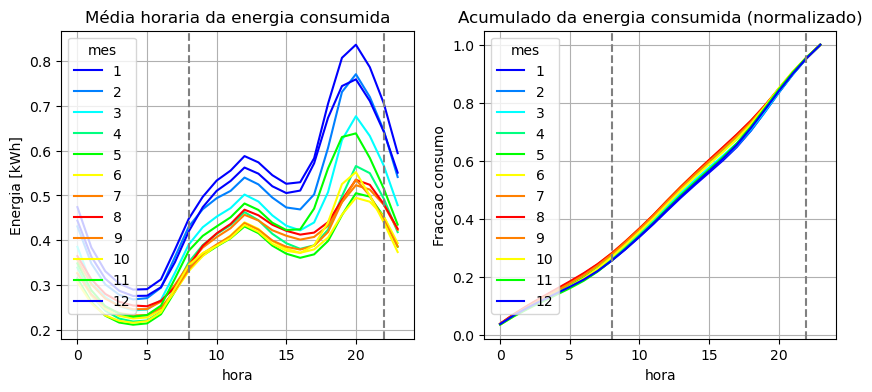

In [6]:
ae.plot_perfil_12x24_medio_e_acumulado(consumo_medio, 'consumo', True, quartohorario=True)

## Produção


In [7]:
# =====================
# Producao
# =====================
ano_producao = 2025 # converter as datas de producao para este ano
# Opcoes API PVGIS
inicio_ano_pvgis = 2005
fim_ano_pvgis = 2023 # PVGIS-SARAH3 na V5.3 (2005-2023)
inclinacao = 30
azimute = 0.0 # azimute = 180 + x; 0 = Sul
perdas = 14 # %
# Lisboa
lat = 38.736
lon = -9.143

In [8]:
producao_lisboa = pvgis.get_pvgis_hourly(lat, lon, inicio_ano_pvgis, fim_ano_pvgis, surface_tilt=inclinacao, surface_azimuth=azimute, peakpower=1, loss=perdas)
producao_lisboa = seriesprod.converter_pvgis_multiyear_ts(producao_lisboa, ano_producao, downscale_para_15min=True)


NEPS Lisboa = 1593 h


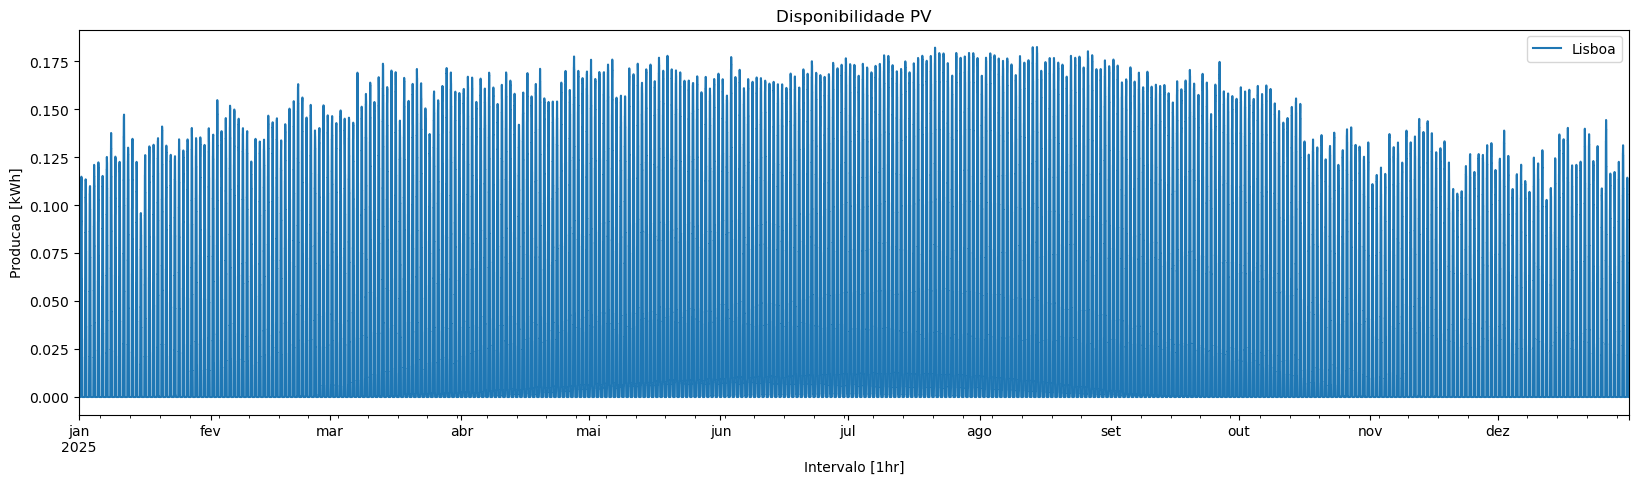

In [9]:
p,ax = plt.subplots(1,1, figsize=(20,5))
producao_lisboa["autoproducao"].plot(ax=ax, label='Lisboa')
plt.legend()
plt.ylabel('Producao [kWh]')
plt.xlabel('Intervalo [1hr]')
plt.title('Disponibilidade PV')

print(f"NEPS Lisboa = {producao_lisboa['autoproducao'].sum():.0f} h")

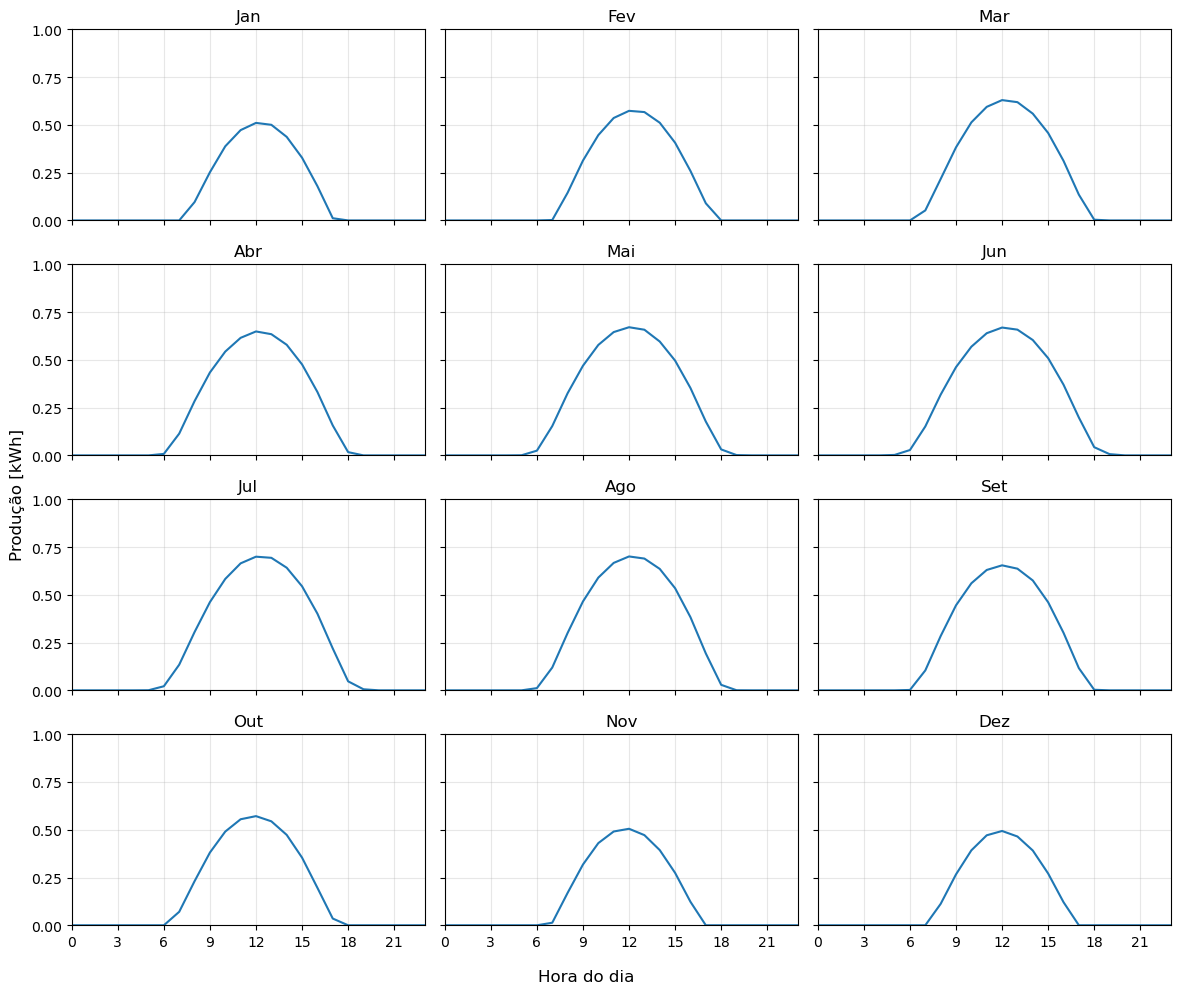

In [10]:
producao12x24 = ae.calcula_12x24(producao_lisboa, 'autoproducao', quartohorario=True)

# obter eixo x como horas em decimal (0..23)
if isinstance(producao12x24.index, pd.DatetimeIndex):
    x = producao12x24.index.hour + producao12x24.index.minute/60.0
else:
    x = producao12x24.index.astype(float)
    
month_short = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}

months = list(producao12x24.columns)
ncols, nrows = 3, 4
fig, axes = plt.subplots(nrows, ncols, sharex=True, sharey=True, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(months[:nrows*ncols]):
    ax = axes[i]
    ax.plot(x, producao12x24[col]) #, marker='o', linestyle='-')
    ax.set_title(month_short.get(col, str(col)))
    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.01, 0.25))
    ax.set_xlim(0, 23)
    ax.set_xticks(np.arange(0, 24, 3))
    ax.grid(alpha=0.3)

# remover eixos não usados se houver menos de 12 colunas
for j in range(len(months), nrows*ncols):
    fig.delaxes(axes[j])

fig.supxlabel('Hora do dia')
fig.supylabel('Produção [kWh]')
plt.tight_layout()
plt.show()

## Precos OMIE 2025

In [11]:
fich_omie = r'./omie/quartos-detalhe-omie-01-01-2025-a-31-12-2025.csv' #os.path.join(os.path.dirname(__file__), "")
precos_omie = precos.ler_serie_omie_tfelicia(fich_omie, unidades='€/MWh')

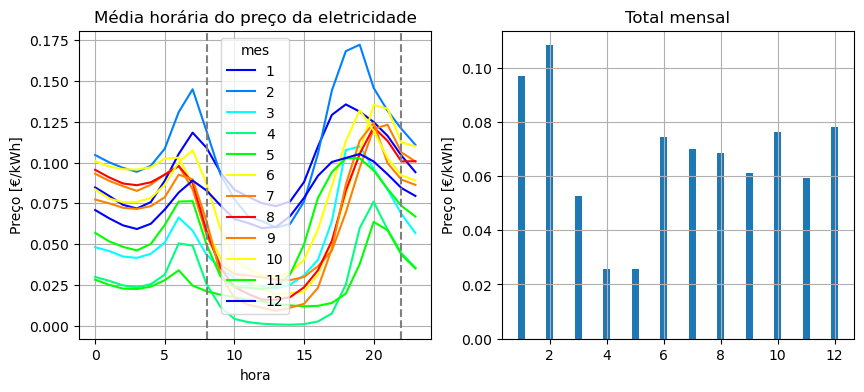

In [15]:
omie_hor = precos_omie['omie'].resample('H').mean().to_frame('omie')
ae.plot_perfil_12x24_e_mensal(omie_hor, 'omie', quartohorario=False, agregacao_mensal='mean', ylabel='Preço [€/kWh]', titulo='Média horária do preço da eletricidade')

## Optimização sem bateria

In [16]:
# =====================
# Sistema
# =====================
params_sistema_sem_bateria = {
    "consumo_anual" : consumo_anual,
    "eficiencia_inversor" : 0.96
}

# =====================
# Custos
# =====================
params_financeiros = {
    "tempo_vida": 20,
    "tempo_vida_bat": 0,
    "pv_por_kW": 0,
    "bat_por_kwh": 0,
    "perc_custo_manutencao": 0.5, # em %
    "taxa_actualizacao": 3,   # em %
    "simples_kWh": 0.129, # Gold energy 10/02
    "vazio_kWh": 0.0894,  # Gold energy 10/02
    "fora_vazio_kWh": 0.1584, # Gold energy 10/02
    "preco_venda_rede": 0.0,
  # Tarifarios indexados
    "omie": precos_omie,
    "tar_simples": 0.06,
    "tar_vazio": 0.02,
    "tar_fora_vazio": 0.08,
    "tarifario_indexado": ape.TarifariosIndexados.CoopernicoBase
}

# precos energia
preco_venda_rede= 0.03 # 3cent/kWh

# Custos PV
custos_pv = np.arange(700,2000,50)

In [ ]:

def estudo_parametrico_sem_bateria(custos, consumo, producao_1kWp, params_sistema, params_financeiros, tarifario_periodo_horario, tipo_tarifario=ape.TipoTarifario.Fixo, max_rpv=10, dt=1):
    """ Estudo paramétrico que varia os custos do PV e encontra o tamanho do sistema que minimiza o LCOE.

    Parameters
    ----------
    custos : List[float]
        Lista com os custos de PV  a analisar. [€/kWp]
    consumo : DataFrame
        Série temporal do consumo na coluna 'consumo'. [kWh]
    producao_1kWp : DataFrame
        Série temporal da produção para 1kWp na coluna 'autoproducao'. [kWh]
    params_sistema : dict
        Dicionario com parametros do sistema com bateria:

        - consumo_anual: total anual. [kWh]
        - eficiencia_inversor : entre [0, 1]. [-]

    params_financeiros : dict
        Dicionario com parametros financeiros para calculo custo energia:

        - tempo_vida: tempo de vida do projecto. [anos]
        - tempo_vida_bat: tempo de vida da bateria. [anos]
        - pv_por_kW: custo de cada kWp instalado de PV. [€/kW]
        - bat_por_kWh: custo de cada kWh instalado de bateria. [€/kWh]
        - reinvestir_bat: considerar reinvestimento numa 2a bateria. [bool]
        - perc_custo_manutencao: percentagem do investimento gasto em manutenção anual. [%]
        - taxa_actualização: taxa de actualização. [%]
        - simples_kWh: preço compra à rede em tarifário simples. Só usado quando tarifario = tarifario.Simples. [€/kWh]
        - vazio_kWh: preço de compra à rede em vazio no tarifario bihorario. Só usado quando tarifario = tarifario.Bihorario. [€/kWh]
        - fora_vazio_kWh: preço de compra à rede fora de vazio no tarifario bihorario. Só usado quando tarifario = tarifario.Bihorario .[€/kWh]
        - preco_venda_rede: Preco de venda da energia à rede. [€/kWh]
    tarifario_periodo_horario : ape.TarifarioPeriodoHorario
        Simples ou Bihorario.
    tipo_tarifario : ape.TipoTarifario, optional
        Tipo de tarifário. The default is ape.TipoTarifario.Fixo.
    max_rpv : float, optional
        Limite máximo para o r_pv. The default is 10. [-]
    dt: float, optional
        Intevalo de tempo. 1 = 1hr, 0.25 = 15min. The default is 1. [-]
        
    Returns
    -------
    resultados : DataFrame
        DataFrame com os resultados do estudo paramétrico. Contém as colunas:
        - custo_bateria: custo da bateria. [€/kWh]
        - r_pv: tamanho do sistema PV. Razão entre produção anual (kWh) e consumo anual (kWh). [-] 
        - LCOE: custo nivelado de energia do sistema. [€/kWh]
        - ias: índice de autoconsumo. [-]
        - iac: índice de autoconsumo. [-]
        - ier: índice de energia renovável. [-]
    """
    LCOE = []
    PV=[]
    resultados = pd.DataFrame()
    for c in custos:
        params_financeiros["pv_por_kW"] = c
        [r_pv, lcoe] = optimiza.optimiza_autoconsumo_sem_bateria(consumo, producao_1kWp, params_sistema, params_financeiros, tarifario_periodo_horario, tipo_tarifario, max_rpv, dt)

        # Recalculating the whole set of values with the optimum inputs:
        neps = producao_1kWp["autoproducao"].sum()
        tot_producao = r_pv * params_sistema["consumo_anual"]
        pot_instalada = tot_producao / neps

        #cap_bat = r_bat * (params_sistema["consumo_anual"]/1000)
        #bat = bateria(cap_bat, params_sistema["soc_min"], params_sistema["soc_max"], params_sistema["eficiencia_bateria"], params_sistema["pot_maxima"])
        energia = consumo.copy()
        energia["autoproducao"] = producao_1kWp["autoproducao"] * pot_instalada

        energia = ae.analisa_upac_sem_armazenamento(energia, intervalo=dt)
        indicadores = ae.calcula_indicadores_autoconsumo(energia, pot_instalada, params_sistema["eficiencia_inversor"], intervalo=dt)
        lcoe, _, _ = af.custo_energia_prosumidor(indicadores, energia["consumo_rede"], tarifario_periodo_horario, tipo_tarifario, params_financeiros)

        resultado = pd.DataFrame({'custo_pv': c, 'r_pv': r_pv, 'LCOE': lcoe, 'ias': indicadores.ias, 'iac': indicadores.iac, 'ier': indicadores.ier}, index=[0])
        resultados = pd.concat([resultados, resultado], ignore_index=True)

    return resultados

def plot_resultados_estudo_parametrico(ax, resultados_estudo, xaxis_var, xaxis_label, titulo, incluir_bateria=False):
    """
    Função para plotar os resultados do estudo paramétrico em 3 subplots na figura fornecida.
    
    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figura matplotlib onde os subplots serão criados.
    resultados_estudo : DataFrame
        Dataframe com os resultados do estudo paramétrico.
    xaxis_var : str
        Nome da variável a ser usada no eixo x (ex: 'custo_pv').
    xaxis_label : str
        Rótulo para o eixo x (ex: 'Cost of PV [EUR/kWp]').
    titulo : str
        Título geral para os subplots.
    incluir_bateria : bool, default: False
        Indica se os resultados com bateria devem ser incluídos nos plots.
    """
    import matplotlib.gridspec as gridspec
    # clear existing content in ax
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_yticks([])
    ax.set_yticklabels([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    fig = ax.figure
    gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=ax)
    
    # Subplot 1: Relative PV sizes
    #ax1 = fig.add_subplot(311)
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(resultados_estudo[xaxis_var], resultados_estudo['r_pv'], label='PV', marker='o', linewidth=2)
    if incluir_bateria:
        ax1.plot(resultados_estudo[xaxis_var], resultados_estudo['r_bat'], linestyle='--',linewidth=2, marker='o',label='Bateria')
    ax1.set_ylabel('Relative PV/Battery sizes [-]')
    ax1.set_ylim(0, 3.0)
    ax1.legend(fontsize=12)
    ax1.grid()
    ax1.set_title(titulo, fontsize=14)
    ax1.set_xticklabels([])  # Remove x-axis labels
    ax1.yaxis.label.set_fontsize(12)
    
    # Subplot 2: LCOE
    #ax2 = fig.add_subplot(312)
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(resultados_estudo[xaxis_var], resultados_estudo['LCOE'], label='LCOE [EUR/MWh]', linewidth=2, marker='o')
    if incluir_bateria:
        ax2.plot(resultados_estudo[xaxis_var], resultados_estudo['LCOS'], linestyle='--',linewidth=2, marker='o',label='LCOS [EUR/MWh]')
    ax2.set_ylabel('LCOE [EUR/MWh]', fontsize=12)
    ax2.legend(loc=4, fontsize=12)
    ax2.grid()
    ax2.set_xticklabels([])  # Remove x-axis labels
    ax2.yaxis.label.set_fontsize(12)
    
    # Subplot 3: Indicadores
    #ax3 = fig.add_subplot(313)
    ax3 = fig.add_subplot(gs[2])
    ax3.plot(resultados_estudo[xaxis_var], resultados_estudo['ias'], label='IAS', marker='o', linewidth=2)
    ax3.plot(resultados_estudo[xaxis_var], resultados_estudo['iac'], linestyle='--', linewidth=2, marker='o', label='IAC')
    ax3.plot(resultados_estudo[xaxis_var], resultados_estudo['ier'], linestyle='--', linewidth=2, label='IER', color='grey')
    ax3.set_xlabel(xaxis_label, fontsize=12)
    ax3.set_ylabel('[%]')
    ax3.set_ylim([20, 100])
    ax3.legend(loc=4, fontsize=12)
    ax3.grid()
   
def plot_2_resultados_estudo_parametrico(ax, res1, sufixo1, res2, sufixo2, xaxis_var, xaxis_label, titulo, incluir_bateria=False):
    """
    """
    import matplotlib.gridspec as gridspec

    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_yticks([])
    ax.set_yticklabels([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    fig = ax.figure
    gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=ax)
    linewidth = 1
    markersize = 4

    # Subplot 1: Relative PV sizes
    #ax1 = fig.add_subplot(311)
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(res1[xaxis_var], res1['r_pv'], label=f'PV {sufixo1}', marker='o', linewidth=linewidth, markersize=markersize)
    ax1.plot(res2[xaxis_var], res2['r_pv'], label=f'PV {sufixo2}', marker='*', linewidth=linewidth, markersize=markersize)
    if incluir_bateria:
        ax1.plot(res1[xaxis_var], res1['r_bat'], linestyle='--',linewidth=2, marker='o',label=f'Bat {sufixo1}')
        ax1.plot(res2[xaxis_var], res2['r_bat'], linestyle='--',linewidth=2, marker='*',label=f'Bat {sufixo2}')
    ax1.set_ylabel('Relative PV/Battery sizes [-]')

    c = [res1['r_pv'].max(), res2['r_pv'].max()]
    #if incluir_bateria:
    #    c.append(res1['r_bat'].max())

    ax1.set_ylim(0, np.ceil(max(c)))
    ax1.legend(fontsize=12)
    ax1.grid()
    ax1.set_title(titulo, fontsize=14)
    ax1.set_xticklabels([])  # Remove x-axis labels
    ax1.yaxis.label.set_fontsize(12)

    # Subplot 2: LCOE
    #ax2 = fig.add_subplot(312)
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(res1[xaxis_var], res1['LCOE'], label=f'LCOE {sufixo1}', linewidth=linewidth, marker='o', markersize=markersize)
    ax2.plot(res2[xaxis_var], res2['LCOE'], label=f'LCOE {sufixo2}', linewidth=linewidth, marker='*', markersize=markersize)
    #if incluir_bateria:
    #    ax2.plot(resultados_estudo[xaxis_var], resultados_estudo['LCOS'], linestyle='--',linewidth=2, marker='o',label='LCOS [EUR/MWh]')
    ax2.set_ylabel('LCOE [EUR/MWh]', fontsize=12)
    ax2.legend(loc=4, fontsize=12)
    ax2.grid()
    ax2.set_xticklabels([])  # Remove x-axis labels
    ax2.yaxis.label.set_fontsize(12)

    # Subplot 3: Indicadores
    #ax3 = fig.add_subplot(313)
    ax3 = fig.add_subplot(gs[2])
    ax3.plot(res1[xaxis_var], res1['ias'], label=f'IAS {sufixo1}', marker='o', linewidth=linewidth, markersize=markersize)
    ax3.plot(res1[xaxis_var], res1['iac'], linestyle='--', linewidth=linewidth, marker='o', label=f'IAC {sufixo1}', markersize=markersize)
    ax3.plot(res2[xaxis_var], res2['ias'], label=f'IAS {sufixo2}', marker='*', linewidth=linewidth, markersize=markersize)
    ax3.plot(res2[xaxis_var], res2['iac'], linestyle='--', linewidth=linewidth, marker='*', label=f'IAC {sufixo2}', markersize=markersize)
    #ax3.plot(resultados_estudo[xaxis_var], resultados_estudo['ier'], linestyle='--', linewidth=linewidth, label='IER', color='grey')
    ax3.set_xlabel(xaxis_label, fontsize=12)
    ax3.set_ylabel('[%]')
    ax3.set_ylim([20, 100])
    ax3.legend(loc=0, fontsize=12)
    ax3.grid()

### Tarifário Fixo

#### Periodo Horário Simples

In [ ]:
# Sem venda à rede
recalcular = False
if os.path.exists(os.path.join(os.curdir, '15min_sem_bat_sem_venda_rede_simples.xlsx')) and not recalcular:
    sem_bat_sem_venda_rede_simples = pd.read_excel('15min_sem_bat_sem_venda_rede_simples.xlsx')
else:
    params_financeiros["preco_venda_rede"] = 0.0
    sem_bat_sem_venda_rede_simples = estudo_parametrico_sem_bateria(custos_pv, 
                                                                consumo_medio, 
                                                                producao_lisboa, 
                                                                params_sistema_sem_bateria, 
                                                                params_financeiros, 
                                                                ape.TarifarioPeriodoHorario.Simples,
                                                                ape.TipoTarifario.Fixo,
                                                                dt=0.25)
    sem_bat_sem_venda_rede_simples.to_excel('15min_sem_bat_sem_venda_rede_simples.xlsx', index=False)



In [44]:
# Com venda à rede
recalcular = True
if os.path.exists(os.path.join(os.curdir, '15min_sem_bat_com_venda_rede_simples.xlsx')) and not recalcular:
    sem_bat_com_venda_rede_simples = pd.read_excel('15min_sem_bat_com_venda_rede_simples.xlsx')
else:
    params_financeiros["preco_venda_rede"] = preco_venda_rede
    sem_bat_com_venda_rede_simples = estudo_parametrico_sem_bateria(custos_pv, 
                                                                consumo_medio, 
                                                                producao_lisboa, 
                                                                params_sistema_sem_bateria, 
                                                                params_financeiros, 
                                                                ape.TarifarioPeriodoHorario.Simples,
                                                                ape.TipoTarifario.Fixo,
                                                                dt=0.25)
    sem_bat_com_venda_rede_simples.to_excel('15min_sem_bat_com_venda_rede_simples.xlsx', index=False)

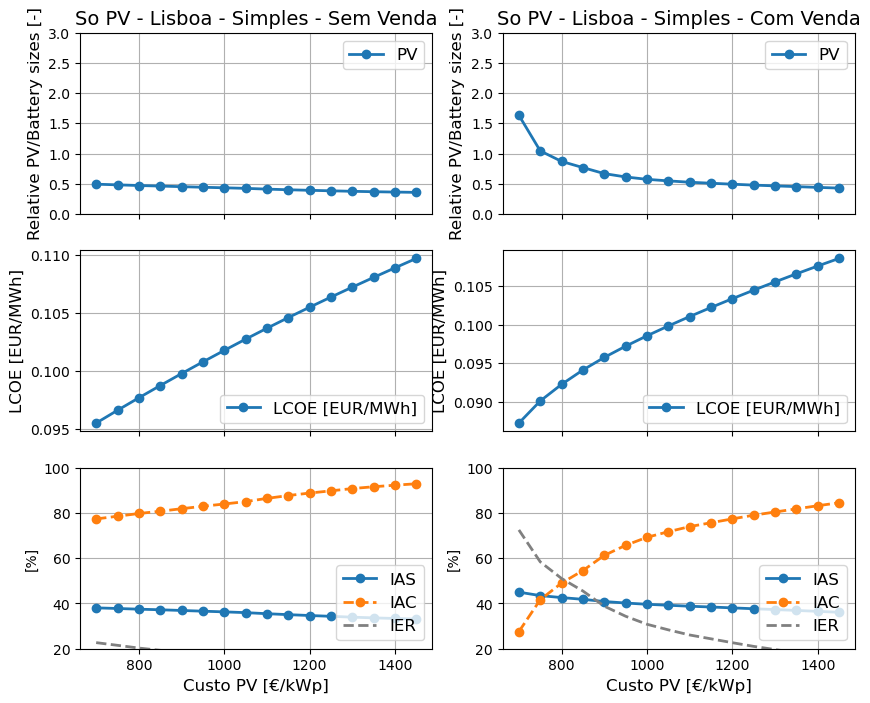

In [45]:
fig, ax = plt.subplots(1, 2, figsize=[10, 8])
plot_resultados_estudo_parametrico(ax[0], sem_bat_sem_venda_rede_simples, 'custo_pv', 'Custo PV [€/kWp]', 'So PV - Lisboa - Simples - Sem Venda', incluir_bateria=False)
plot_resultados_estudo_parametrico(ax[1], sem_bat_com_venda_rede_simples, 'custo_pv', 'Custo PV [€/kWp]', 'So PV - Lisboa - Simples - Com Venda', incluir_bateria=False)
# Aqui você pode usar ax[1] para outro plot se necessário
#plt.tight_layout()
plt.show()

#### Periodo Horário Bihorario

In [ ]:
# Sem venda à rede
recalcular = False
if os.path.exists(os.path.join(os.curdir, '15min_sem_bat_sem_venda_rede_bihorario.xlsx')) and not recalcular:
    sem_bat_sem_venda_rede_bihorario = pd.read_excel('15min_sem_bat_sem_venda_rede_bihorario.xlsx')
else:
    params_financeiros["preco_venda_rede"] = 0.0
    sem_bat_sem_venda_rede_bihorario = estudo_parametrico_sem_bateria(custos_pv, 
                                                                    consumo_medio, 
                                                                    producao_lisboa, 
                                                                    params_sistema_sem_bateria, 
                                                                    params_financeiros, 
                                                                    ape.TarifarioPeriodoHorario.Bihorario,
                                                                    ape.TipoTarifario.Fixo,
                                                                    dt=0.25)
    sem_bat_sem_venda_rede_bihorario.to_excel('15min_sem_bat_sem_venda_rede_bihorario.xlsx', index=False)

In [ ]:
# Com venda à rede
recalcular = False
if os.path.exists(os.path.join(os.curdir, '15min_sem_bat_com_venda_rede_bihorario.xlsx')) and not recalcular:
    sem_bat_com_venda_rede_bihorario = pd.read_excel('15min_sem_bat_com_venda_rede_bihorario.xlsx')
else:
    params_financeiros["preco_venda_rede"] = preco_venda_rede
    sem_bat_com_venda_rede_bihorario = estudo_parametrico_sem_bateria(custos_pv, 
                                                                consumo_medio, 
                                                                producao_lisboa, 
                                                                params_sistema_sem_bateria, 
                                                                params_financeiros, 
                                                                ape.TarifarioPeriodoHorario.Bihorario,
                                                                ape.TipoTarifario.Fixo,
                                                                dt=0.25)
    sem_bat_com_venda_rede_bihorario.to_excel('15min_sem_bat_com_venda_rede_bihorario.xlsx', index=False)

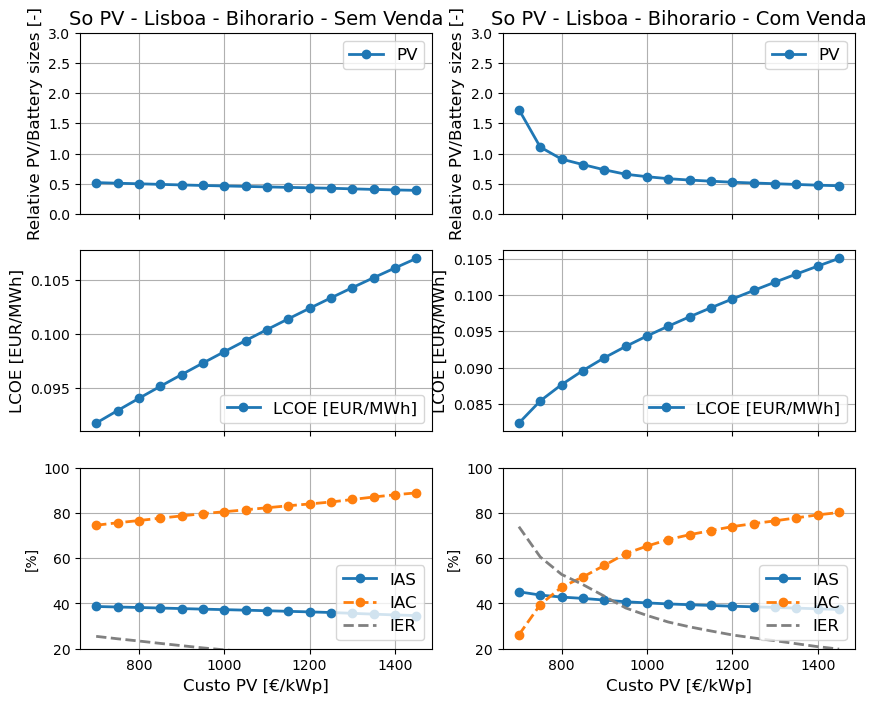

In [48]:
fig, ax = plt.subplots(1, 2, figsize=[10, 8])
plot_resultados_estudo_parametrico(ax[0], sem_bat_sem_venda_rede_bihorario, 'custo_pv', 'Custo PV [€/kWp]', 'So PV - Lisboa - Bihorario - Sem Venda', incluir_bateria=False)
plot_resultados_estudo_parametrico(ax[1], sem_bat_com_venda_rede_bihorario, 'custo_pv', 'Custo PV [€/kWp]', 'So PV - Lisboa - Bihorario - Com Venda', incluir_bateria=False)
# Aqui você pode usar ax[1] para outro plot se necessário
#plt.tight_layout()
plt.show()

#### Plots

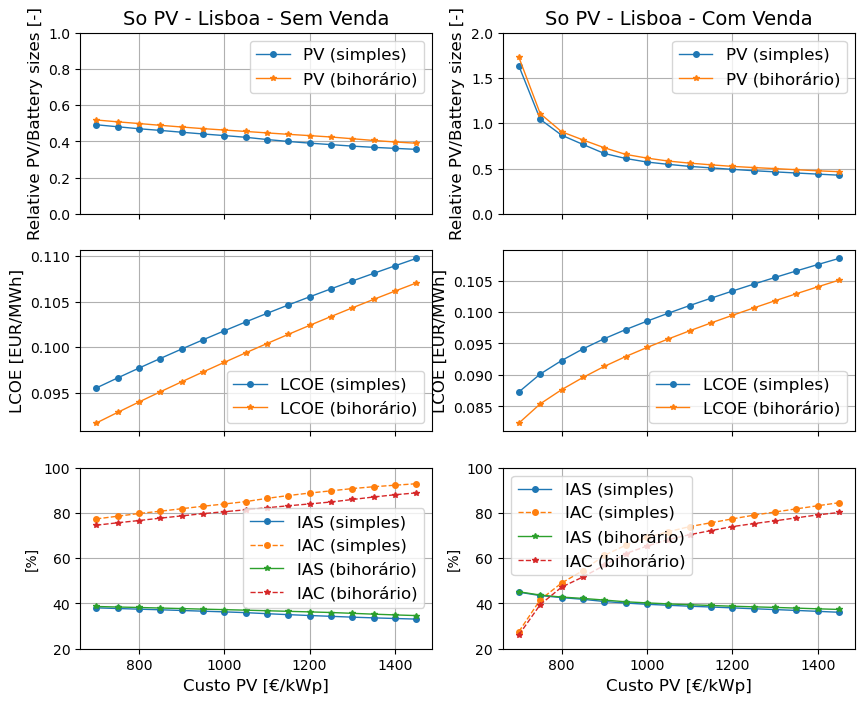

In [49]:
fig, ax = plt.subplots(1, 2, figsize=[10, 8])
plot_2_resultados_estudo_parametrico(ax[0], sem_bat_sem_venda_rede_simples, '(simples)', sem_bat_sem_venda_rede_bihorario, '(bihorário)', 'custo_pv', 'Custo PV [€/kWp]', 'So PV - Lisboa - Sem Venda', incluir_bateria=False)
plot_2_resultados_estudo_parametrico(ax[1], sem_bat_com_venda_rede_simples, '(simples)', sem_bat_com_venda_rede_bihorario, '(bihorário)', 'custo_pv', 'Custo PV [€/kWp]', 'So PV - Lisboa - Com Venda', incluir_bateria=False)

### Tarifário Indexado

#### Periodo Horario Bihorario

In [ ]:
# Sem venda à rede
recalcular = False
if os.path.exists(os.path.join(os.curdir, '15min_sem_bat_sem_venda_rede_indexado_bihorario.xlsx')) and not recalcular:
    sem_bat_sem_venda_rede_indexado_bihorario = pd.read_excel('15min_sem_bat_sem_venda_rede_indexado_bihorario.xlsx')
else:
    params_financeiros["preco_venda_rede"] = 0.0
    sem_bat_sem_venda_rede_indexado_bihorario = estudo_parametrico_sem_bateria(custos_pv, 
                                                                            consumo_medio, 
                                                                            producao_lisboa, 
                                                                            params_sistema_sem_bateria, 
                                                                            params_financeiros, 
                                                                            ape.TarifarioPeriodoHorario.Bihorario,
                                                                            ape.TipoTarifario.Indexado,
                                                                            dt=0.25)
    sem_bat_sem_venda_rede_indexado_bihorario.to_excel('15min_sem_bat_sem_venda_rede_indexado_bihorario.xlsx', index=False)

In [ ]:
# Com venda à rede
recalcular = False
if os.path.exists(os.path.join(os.curdir, '15min_sem_bat_com_venda_rede_indexado_bihorario.xlsx')) and not recalcular:
    sem_bat_com_venda_rede_indexado_bihorario = pd.read_excel('15min_sem_bat_com_venda_rede_indexado_bihorario.xlsx')
else:
    params_financeiros["preco_venda_rede"] = preco_venda_rede
    sem_bat_com_venda_rede_indexado_bihorario = estudo_parametrico_sem_bateria(custos_pv, 
                                                                            consumo_medio, 
                                                                            producao_lisboa, 
                                                                            params_sistema_sem_bateria, 
                                                                            params_financeiros, 
                                                                            ape.TarifarioPeriodoHorario.Bihorario,
                                                                            ape.TipoTarifario.Indexado,
                                                                            dt=0.25)
    sem_bat_com_venda_rede_indexado_bihorario.to_excel('15min_sem_bat_com_venda_rede_indexado_bihorario.xlsx', index=False)

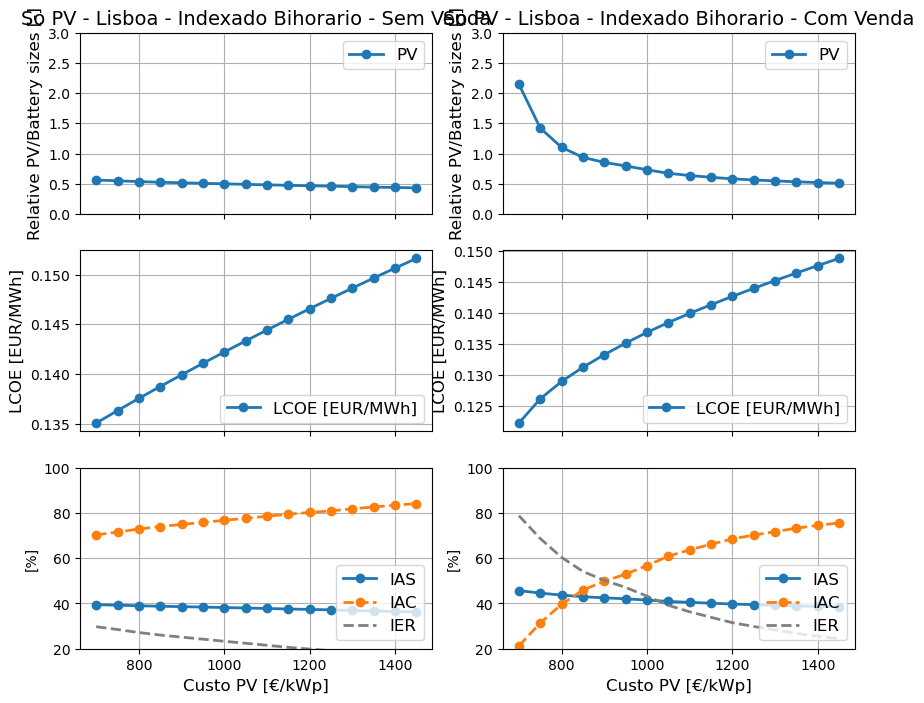

In [52]:
fig, ax = plt.subplots(1, 2, figsize=[10, 8])
plot_resultados_estudo_parametrico(ax[0], sem_bat_sem_venda_rede_indexado_bihorario, 'custo_pv', 'Custo PV [€/kWp]', 'So PV - Lisboa - Indexado Bihorario - Sem Venda', incluir_bateria=False)
plot_resultados_estudo_parametrico(ax[1], sem_bat_com_venda_rede_indexado_bihorario, 'custo_pv', 'Custo PV [€/kWp]', 'So PV - Lisboa - Indexado Bihorario - Com Venda', incluir_bateria=False)
# Aqui você pode usar ax[1] para outro plot se necessário
#plt.tight_layout()
plt.show()

## Optimização com bateria

In [31]:
# =====================
# Sistema
# =====================
params_sistema_com_bateria = {
    "consumo_anual" : consumo_anual,
    "eficiencia_inversor" : 0.96,
    "eficiencia_bateria" : 0.92,
    "soc_min" : 0.2,
    "soc_max" : 1.0,
    "pot_maxima" : 5 # kW
}

# =====================
# Custos
# =====================
params_financeiros = {
    "tempo_vida": 20,
    "tempo_vida_bat": 10,
    "pv_por_kW": 1000,
    "bat_por_kWh": 0, # parametro a variar
    "reinvestir_bat": False, # considerar 2a bateria apos tempo de vida
    "perc_custo_manutencao": 0.5, # em %
    "taxa_actualizacao": 3,   # em %
    "simples_kWh": 0.129, # Gold energy 10/02
    "vazio_kWh": 0.0894,  # Gold energy 10/02
    "fora_vazio_kWh": 0.1584, # Gold energy 10/02
    "preco_venda_rede": 0.0,
  # Tarifarios indexados
    "omie": precos_omie,
    "tar_simples": 0.06,
    "tar_vazio": 0.02,
    "tar_fora_vazio": 0.08,
    "tarifario_indexado": ape.TarifariosIndexados.CoopernicoBase
}

# precos energia
preco_venda_rede= 0.03 # 4cent/kWh

# Custos bat
# Custos PV
custos_pv = np.arange(700,1500,50)
custos_bat = np.arange(100,500,20)  

In [ ]:
def estudo_parametrico_custos_bateria(custos, consumo, producao_1kWp, params_sistema, params_financeiros, tarifario_periodo_horario, tipo_tarifario=ape.TipoTarifario.Fixo, max_rpv=10):
    """ Estudo paramétrico que varia os custo da bateria e encontra o tamanho do sistema optimo que minimiza o LCOE.

    Parameters
    ----------
    custos : List[float]
        Lista com os custos da bateria a analisar. [€/kWh]
    consumo : DataFrame
        Série temporal do consumo na coluna 'consumo'. [kWh]
    producao_1kWp : DataFrame
        Série temporal da produção para 1kWp na coluna 'autoproducao'. [kWh]
    params_sistema : dict
        Dicionario com parametros do sistema com bateria:

        - consumo_anual: total anual. [kWh]
        - eficiencia_inversor : entre [0, 1]. [-]
        - eficiencia_bateria : eficiencia entre carga e descarga, entre [0, 1]. [-]
        - soc_min : estado de carga minimo em fraccao da capacidade, entre [0, 1]. [-]
        - soc_max : estado de carga máximo em fraccao da capacidade, entre [0, 1]. [-]
        - pot_maxima : potencia máxima que pode ser fornecida/retirada da bateria. [kW]

    params_financeiros : dict
        Dicionario com parametros financeiros para calculo custo energia:

        - tempo_vida: tempo de vida do projecto. [anos]
        - tempo_vida_bat: tempo de vida da bateria. [anos]
        - pv_por_kW: custo de cada kWp instalado de PV. [€/kW]
        - bat_por_kWh: custo de cada kWh instalado de bateria. [€/kWh]
        - reinvestir_bat: considerar reinvestimento numa 2a bateria. [bool]
        - perc_custo_manutencao: percentagem do investimento gasto em manutenção anual. [%]
        - taxa_actualização: taxa de actualização. [%]
        - simples_kWh: preço compra à rede em tarifário simples. Só usado quando tarifario = tarifario.Simples. [€/kWh]
        - vazio_kWh: preço de compra à rede em vazio no tarifario bihorario. Só usado quando tarifario = tarifario.Bihorario. [€/kWh]
        - fora_vazio_kWh: preço de compra à rede fora de vazio no tarifario bihorario. Só usado quando tarifario = tarifario.Bihorario .[€/kWh]
        - preco_venda_rede: Preco de venda da energia à rede. [€/kWh]
    tarifario_periodo_horario : ape.TarifarioPeriodoHorario
        Simples ou Bihorario.
    tipo_tarifario : ape.TipoTarifario, optional
        Tipo de tarifário. The default is ape.TipoTarifario.Fixo.
    max_rpv : float, optional
        Limite máximo para o r_pv. The default is 10. [-]

    Returns
    -------
    resultados : DataFrame
        DataFrame com os resultados do estudo paramétrico. Contém as colunas:
        - custo_bateria: custo da bateria. [€/kWh]
        - r_pv: tamanho do sistema PV. Razão entre produção anual (kWh) e consumo anual (kWh). [-] 
        - r_bat: tamanho da bateria. Razão entre capacidade da bateria (kWh) e consumo anual (MWh). [-]
        - LCOE: custo nivelado de energia do sistema. [€/kWh]
        - LCOS: custo nivelado de armazenamento do sistema. [€/kWh]
        - ias: índice de autoconsumo. [-]
        - iac: índice de autoconsumo. [-]
        - ier: índice de energia renovável. [-]
    """
    LCOE = []
    BAT = []
    PV=[]
    LCOS = []   
    resultados = pd.DataFrame()

    for c in custos:    
        # Optimisation
        params_financeiros["bat_por_kWh"] = c
        [r_pv, r_bat, lcoe] = optimiza.optimiza_autoconsumo_com_bateria(consumo, producao_1kWp, params_sistema, params_financeiros, tarifario_periodo_horario, tipo_tarifario, max_rpv)
        #BAT.append(r_bat)    
        #LCOE.append(lcoe)
        #PV.append(r_pv)
        
        # Recalculating the whole set of values with the optimum inputs:
        neps = producao_1kWp["autoproducao"].sum()
        tot_producao = r_pv * params_sistema["consumo_anual"]
        pot_instalada = tot_producao / neps

        cap_bat = r_bat * (params_sistema["consumo_anual"]/1000)
        bat = bateria(cap_bat, params_sistema["soc_min"], params_sistema["soc_max"], params_sistema["eficiencia_bateria"], params_sistema["pot_maxima"])
        energia = consumo.copy()
        energia["autoproducao"] = producao_1kWp["autoproducao"] * pot_instalada

        energia = ae.analisa_upac_com_armazenamento(energia, bat, eficiencia_inversor=params_sistema["eficiencia_inversor"])
        indicadores = ae.calcula_indicadores_autoconsumo(energia, pot_instalada, params_sistema["eficiencia_inversor"], bat)
        lcoe, lcos, _ = af.custo_energia_prosumidor(indicadores, energia["consumo_rede"], tarifario_periodo_horario, tipo_tarifario, params_financeiros)
        #LCOE.append(lcoe)
        #LCOS.append(lcos)

        #ae.plot_despacho_energia(energia, 30)
        resultado = pd.DataFrame({'custo_bateria': c, 'r_pv': r_pv, 'r_bat': r_bat, 'LCOE': lcoe, 'LCOS': lcos, 'ias': indicadores.ias, 'iac': indicadores.iac, 'ier': indicadores.ier}, index=[0])
        resultados = pd.concat([resultados, resultado], ignore_index=True)

    return resultados

def estudo_parametrico_custos_pv_bateria(custos_pv, custos_bat, consumo, producao_1kWp, params_sistema, params_financeiros, tarifario_periodo_horario, tipo_tarifario=ape.TipoTarifario.Fixo, max_rpv=10):
    """ Estudo paramétrico que varia os custo da bateria e encontra o tamanho do sistema optimo que minimiza o LCOE.

    Parameters
    ----------
    custos : List[float]
        Lista com os custos da bateria a analisar. [€/kWh]
    consumo : DataFrame
        Série temporal do consumo na coluna 'consumo'. [kWh]
    producao_1kWp : DataFrame
        Série temporal da produção para 1kWp na coluna 'autoproducao'. [kWh]
    params_sistema : dict
        Dicionario com parametros do sistema com bateria:

        - consumo_anual: total anual. [kWh]
        - eficiencia_inversor : entre [0, 1]. [-]
        - eficiencia_bateria : eficiencia entre carga e descarga, entre [0, 1]. [-]
        - soc_min : estado de carga minimo em fraccao da capacidade, entre [0, 1]. [-]
        - soc_max : estado de carga máximo em fraccao da capacidade, entre [0, 1]. [-]
        - pot_maxima : potencia máxima que pode ser fornecida/retirada da bateria. [kW]

    params_financeiros : dict
        Dicionario com parametros financeiros para calculo custo energia:

        - tempo_vida: tempo de vida do projecto. [anos]
        - tempo_vida_bat: tempo de vida da bateria. [anos]
        - pv_por_kW: custo de cada kWp instalado de PV. [€/kW]
        - bat_por_kWh: custo de cada kWh instalado de bateria. [€/kWh]
        - reinvestir_bat: considerar reinvestimento numa 2a bateria. [bool]
        - perc_custo_manutencao: percentagem do investimento gasto em manutenção anual. [%]
        - taxa_actualização: taxa de actualização. [%]
        - simples_kWh: preço compra à rede em tarifário simples. Só usado quando tarifario = tarifario.Simples. [€/kWh]
        - vazio_kWh: preço de compra à rede em vazio no tarifario bihorario. Só usado quando tarifario = tarifario.Bihorario. [€/kWh]
        - fora_vazio_kWh: preço de compra à rede fora de vazio no tarifario bihorario. Só usado quando tarifario = tarifario.Bihorario .[€/kWh]
        - preco_venda_rede: Preco de venda da energia à rede. [€/kWh]
    tarifario_periodo_horario : ape.TarifarioPeriodoHorario
        Simples ou Bihorario.
    tipo_tarifario : ape.TipoTarifario, optional
        Tipo de tarifário. The default is ape.TipoTarifario.Fixo.
    max_rpv : float, optional
        Limite máximo para o r_pv. The default is 10. [-]

    Returns
    -------
    resultados : DataFrame
        DataFrame com os resultados do estudo paramétrico. Contém as colunas:
        - custo_bateria: custo da bateria. [€/kWh]
        - r_pv: tamanho do sistema PV. Razão entre produção anual (kWh) e consumo anual (kWh). [-] 
        - r_bat: tamanho da bateria. Razão entre capacidade da bateria (kWh) e consumo anual (MWh). [-]
        - LCOE: custo nivelado de energia do sistema. [€/kWh]
        - LCOS: custo nivelado de armazenamento do sistema. [€/kWh]
        - ias: índice de autoconsumo. [-]
        - iac: índice de autoconsumo. [-]
        - ier: índice de energia renovável. [-]
    """
    LCOE = []
    BAT = []
    PV=[]
    LCOS = []   
    resultados = pd.DataFrame()

    for c_pv in custos_pv:
        for c_bat in custos_bat:    
            # Optimisation
            params_financeiros["pv_por_kW"] = c_pv
            params_financeiros["bat_por_kWh"] = c_bat
            [r_pv, r_bat, lcoe] = optimiza_autoconsumo_com_bateria(consumo, producao_1kWp, params_sistema, params_financeiros, tarifario_periodo_horario, tipo_tarifario, max_rpv)
            #BAT.append(r_bat)    
            #LCOE.append(lcoe)
            #PV.append(r_pv)
            
            # Recalculating the whole set of values with the optimum inputs:
            neps = producao_1kWp["autoproducao"].sum()
            tot_producao = r_pv * params_sistema["consumo_anual"]
            pot_instalada = tot_producao / neps

            cap_bat = r_bat * (params_sistema["consumo_anual"]/1000)
            bat = bateria(cap_bat, params_sistema["soc_min"], params_sistema["soc_max"], params_sistema["eficiencia_bateria"], params_sistema["pot_maxima"])
            energia = consumo.copy()
            energia["autoproducao"] = producao_1kWp["autoproducao"] * pot_instalada

            energia = ae.analisa_upac_com_armazenamento(energia, bat, eficiencia_inversor=params_sistema["eficiencia_inversor"])
            indicadores = ae.calcula_indicadores_autoconsumo(energia, pot_instalada, params_sistema["eficiencia_inversor"], bat)
            lcoe, lcos, _ = af.custo_energia_prosumidor(indicadores, energia["consumo_rede"], tarifario_periodo_horario, tipo_tarifario, params_financeiros)
            #LCOE.append(lcoe)
            #LCOS.append(lcos)

            #ae.plot_despacho_energia(energia, 30)
            resultado = pd.DataFrame({'custo_pv': c_pv, 'custo_bateria': c_bat, 'r_pv': r_pv, 'r_bat': r_bat, 'LCOE': lcoe, 'LCOS': lcos, 'ias': indicadores.ias, 'iac': indicadores.iac, 'ier': indicadores.ier}, index=[0])
            resultados = pd.concat([resultados, resultado], ignore_index=True)

    return resultados

### Tarifario Fixo

#### Periodo Horário Simples

In [ ]:
# Sem venda à rede
recalcular = False
if os.path.exists(os.path.join(os.curdir, '15min_com_bat_sem_venda_rede_simples.xlsx')) and not recalcular:
    com_bat_sem_venda_rede_simples = pd.read_excel('15min_com_bat_sem_venda_rede_simples.xlsx')
else:
    params_financeiros["preco_venda_rede"] = 0.0
    com_bat_sem_venda_rede_simples = estudo_parametrico_custos_bateria(custos_bat, 
                                                            consumo_medio, 
                                                            producao_lisboa, 
                                                            params_sistema_com_bateria, 
                                                            params_financeiros, 
                                                            ape.TarifarioPeriodoHorario.Simples)
    com_bat_sem_venda_rede_simples.to_excel('15min_com_bat_sem_venda_rede_simples.xlsx', index=False)

In [ ]:
# Com venda à rede
recalcular = False
if os.path.exists(os.path.join(os.curdir, '15min_com_bat_com_venda_rede_simples.xlsx')) and not recalcular:
    com_bat_com_venda_rede_simples = pd.read_excel('15min_com_bat_com_venda_rede_simples.xlsx')
else:
    params_financeiros["preco_venda_rede"] = preco_venda_rede
    com_bat_com_venda_rede_simples = estudo_parametrico_custos_bateria(custos_bat, 
                                                            consumo_medio, 
                                                            producao_lisboa, 
                                                            params_sistema_com_bateria, 
                                                            params_financeiros, 
                                                            ape.TarifarioPeriodoHorario.Simples)
    com_bat_com_venda_rede_simples.to_excel('15min_com_bat_com_venda_rede_simples.xlsx', index=False)

In [47]:
#fig, ax = plt.subplots(1, 2, figsize=[10, 8])
#plot_resultados_estudo_parametrico(ax[0], com_bat_sem_venda_rede_simples, 'custo_bateria', 'Custo BAT [€/kWh]', 'BAT - Lisboa - Simples - Sem Venda', incluir_bateria=True)
#plot_resultados_estudo_parametrico(ax[1], com_bat_com_venda_rede_simples, 'custo_bateria', 'Custo BAT [€/kWp]', 'BAT - Lisboa - Simples - Com Venda', incluir_bateria=True)
#plt.show()

#### Periodo Horario Bihorario

In [ ]:
# Sem venda à rede
recalcular = False
if os.path.exists(os.path.join(os.curdir, '15min_com_bat_sem_venda_rede_bihorario.xlsx')) and not recalcular:
    com_bat_sem_venda_rede_bihorario = pd.read_excel('15min_com_bat_sem_venda_rede_bihorario.xlsx')
else:
    params_financeiros["preco_venda_rede"] = 0.0
    com_bat_sem_venda_rede_bihorario = estudo_parametrico_custos_bateria(custos_bat, 
                                                            consumo_medio, 
                                                            producao_lisboa, 
                                                            params_sistema_com_bateria, 
                                                            params_financeiros, 
                                                            ape.TarifarioPeriodoHorario.Bihorario)
    com_bat_sem_venda_rede_bihorario.to_excel('15min_com_bat_sem_venda_rede_bihorario.xlsx', index=False)

In [ ]:
# Com venda à rede
#custos_bat = np.arange(100, 700, 20)  
recalcular = False
if os.path.exists(os.path.join(os.curdir, '15min_com_bat_com_venda_rede_bihorario.xlsx')) and not recalcular:
    com_bat_com_venda_rede_bihorario = pd.read_excel('15min_com_bat_com_venda_rede_bihorario.xlsx')
else:
    params_financeiros["preco_venda_rede"] = preco_venda_rede
    com_bat_com_venda_rede_bihorario = estudo_parametrico_custos_bateria(custos_bat, 
                                                            consumo_medio, 
                                                            producao_lisboa, 
                                                            params_sistema_com_bateria, 
                                                            params_financeiros, 
                                                            ape.TarifarioPeriodoHorario.Bihorario)
    com_bat_com_venda_rede_bihorario.to_excel('15min_com_bat_com_venda_rede_bihorario.xlsx', index=False)

#### Plots

#### Comparar com venda e sem venda

* Com venda mais rentável, menor LCOE
* Sistemas PV maiores com venda, tamanaho bateria igual


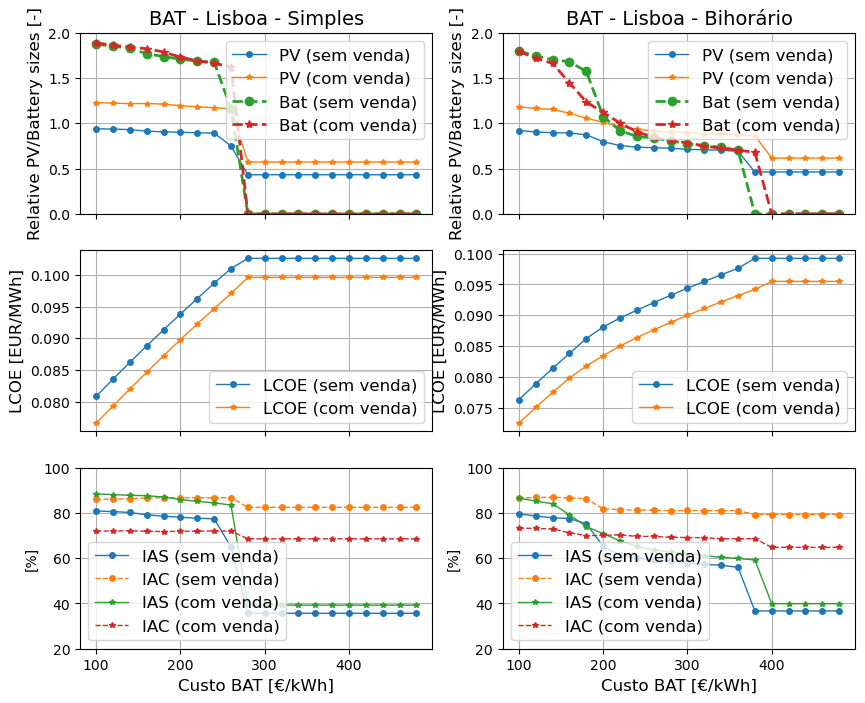

In [37]:
fig, ax = plt.subplots(1, 2, figsize=[10, 8])
#plot_resultados_estudo_parametrico(ax[0], com_bat_sem_venda_rede_simples, 'custo_bateria', 'Custo BAT [€/kWh]', 'BAT - Lisboa - Simples - Sem Venda', incluir_bateria=True)
#plot_resultados_estudo_parametrico(ax[1], com_bat_com_venda_rede_simples, 'custo_bateria', 'Custo BAT [€/kWp]', 'BAT - Lisboa - Simples - Com Venda', incluir_bateria=True)

plot_2_resultados_estudo_parametrico(ax[0], com_bat_sem_venda_rede_simples, '(sem venda)', com_bat_com_venda_rede_simples, '(com venda)', 'custo_bateria', 'Custo BAT [€/kWh]', 'BAT - Lisboa - Simples', incluir_bateria=True)
plot_2_resultados_estudo_parametrico(ax[1], com_bat_sem_venda_rede_bihorario, '(sem venda)', com_bat_com_venda_rede_bihorario, '(com venda)', 'custo_bateria', 'Custo BAT [€/kWh]', 'BAT - Lisboa - Bihorário', incluir_bateria=True)
# Aqui você pode usar ax[1] para outro plot se necessário
#plt.tight_layout()
plt.show()

##### Comparar simple com bihorario com venda

* Custo de energia mais baixo com bihorario
* Com simples tamanho do sistema para cobrir IAS 80% do consumo
* Com bihorario tamanho do sistema para cobrir fora vazio IAS 60%


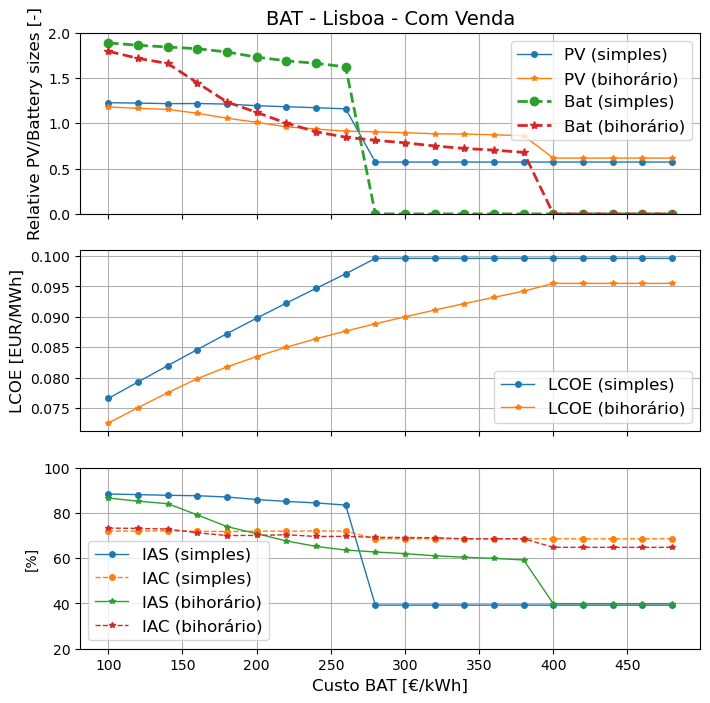

In [38]:
fig, ax = plt.subplots(1, 1, figsize=[8, 8])
plot_2_resultados_estudo_parametrico(ax, com_bat_com_venda_rede_simples, '(simples)', com_bat_com_venda_rede_bihorario, '(bihorário)', 'custo_bateria', 'Custo BAT [€/kWh]', 'BAT - Lisboa - Com Venda', incluir_bateria=True)

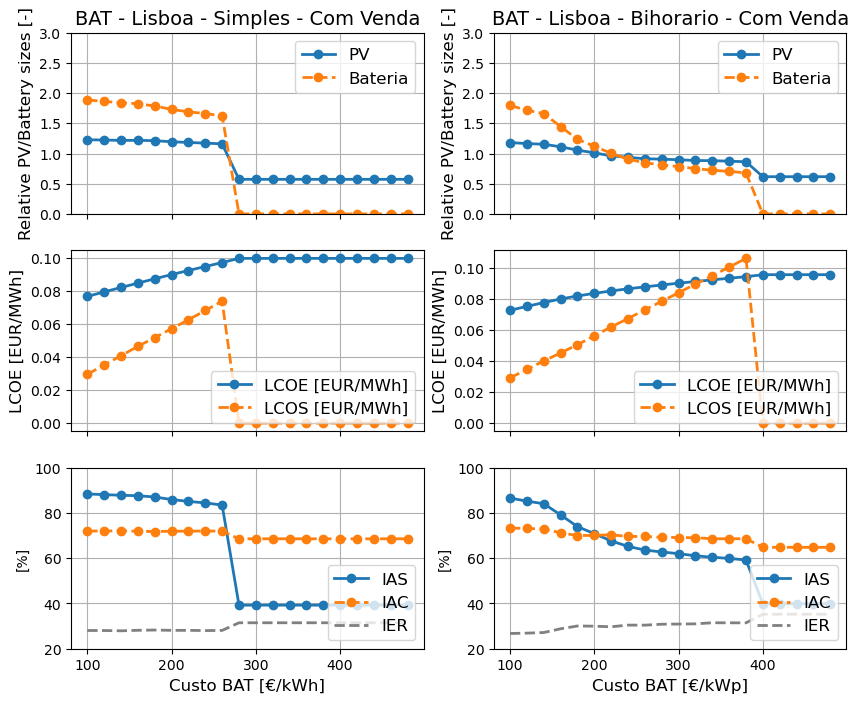

In [45]:
fig, ax = plt.subplots(1, 2, figsize=[10, 8])
plot_resultados_estudo_parametrico(ax[0], com_bat_com_venda_rede_simples, 'custo_bateria', 'Custo BAT [€/kWh]', 'BAT - Lisboa - Simples - Com Venda', incluir_bateria=True)
plot_resultados_estudo_parametrico(ax[1], com_bat_com_venda_rede_bihorario, 'custo_bateria', 'Custo BAT [€/kWp]', 'BAT - Lisboa - Bihorario - Com Venda', incluir_bateria=True)
# Aqui você pode usar ax[1] para outro plot se necessário
#plt.tight_layout()
plt.show()

NOTAS:
consumo medio 3.6MWh/ano
Custo bateria mto baixo 200€/kWh
* r_pv = 1 => 2,26 kWp , r_bat = 1.7 => 6,12 kWh
* bateria no verao/outono cobre quase todo o consumo fora das horas solares, menos inicio da manha

* r_pv = 0.8 => 1,8kWp, r_bat = 0.8 => 2,88 kWh
* bateria no verao/outono cobre ~periodo fora vazio, vazio consumo da rede

#### Despacho

In [ ]:
# Custo Bat 180€/kWh r_pv = 1.0, r_bat = 1.7 (simples)
# Custo Bat 400€/kWh r_pv = 0.8, r_bat = 0.8 (bihorario)
r_pv_teste = 0.8
r_bat_teste = 0.8
neps = producao_lisboa["autoproducao"].sum()
tot_producao = r_pv_teste * params_sistema_com_bateria["consumo_anual"]
pot_instalada = tot_producao / neps

cap_bat = r_bat_teste * (params_sistema_com_bateria["consumo_anual"]/1000)
bat = bateria(cap_bat, params_sistema_com_bateria["soc_min"], params_sistema_com_bateria["soc_max"], params_sistema_com_bateria["eficiencia_bateria"], params_sistema_com_bateria["pot_maxima"])
energia = consumo_medio.copy()
energia["autoproducao"] = producao_lisboa["autoproducao"] * pot_instalada

energia = ae.analisa_upac_com_armazenamento(energia, bat, eficiencia_inversor=params_sistema_com_bateria["eficiencia_inversor"])
indicadores = ae.calcula_indicadores_autoconsumo(energia, pot_instalada, params_sistema_com_bateria["eficiencia_inversor"], bat)
lcoe, lcos, _ = af.custo_energia_prosumidor(indicadores, ape.TarifarioPeriodoHorario.Bihorario, params_financeiros)
print('LCOE: ' + str(lcoe) + ' €/kWh')
print('LCOS: ' + str(lcos) + ' €/kWh')

LCOE: 0.10091393391379026 €/kWh
LCOS: 0.14253169158200946 €/kWh


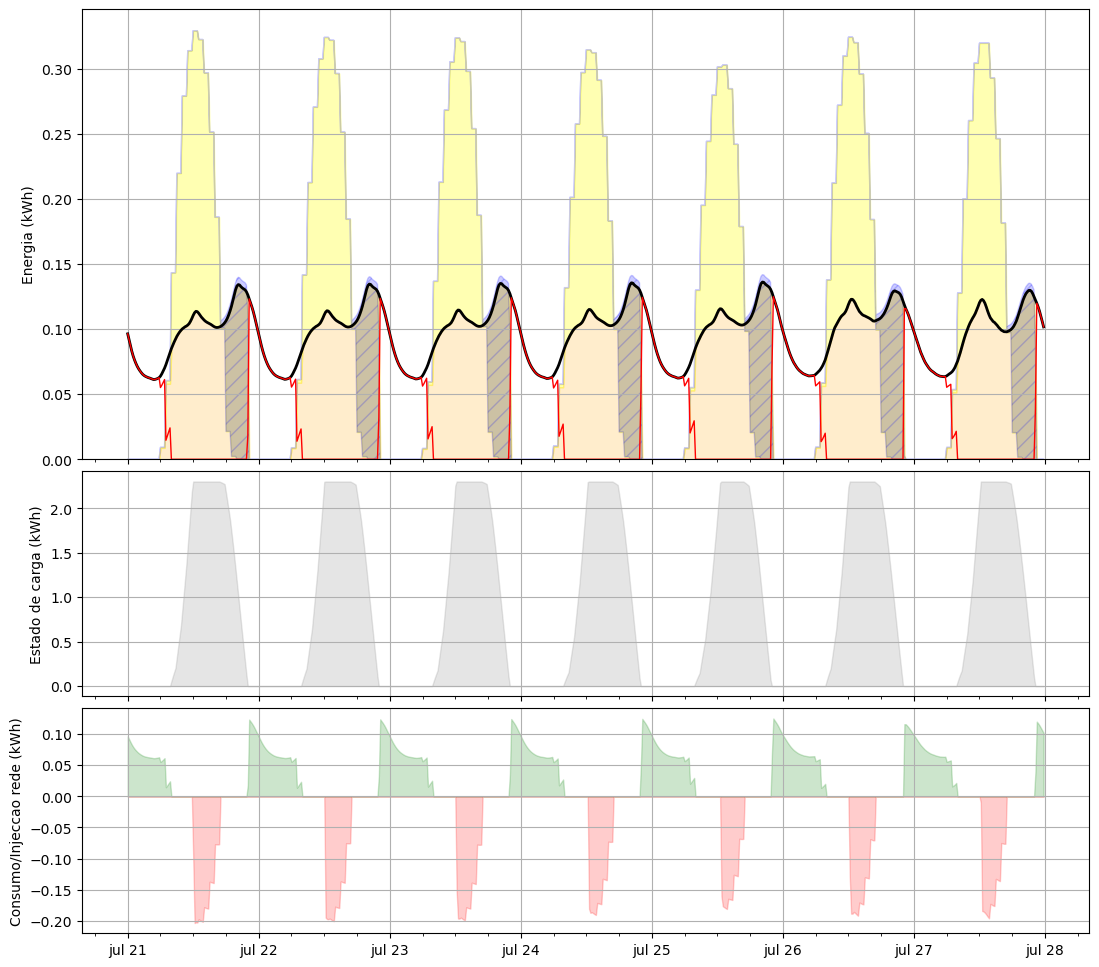

In [29]:
# plot despacho verao
ae.plot_despacho_energia(energia, 30)

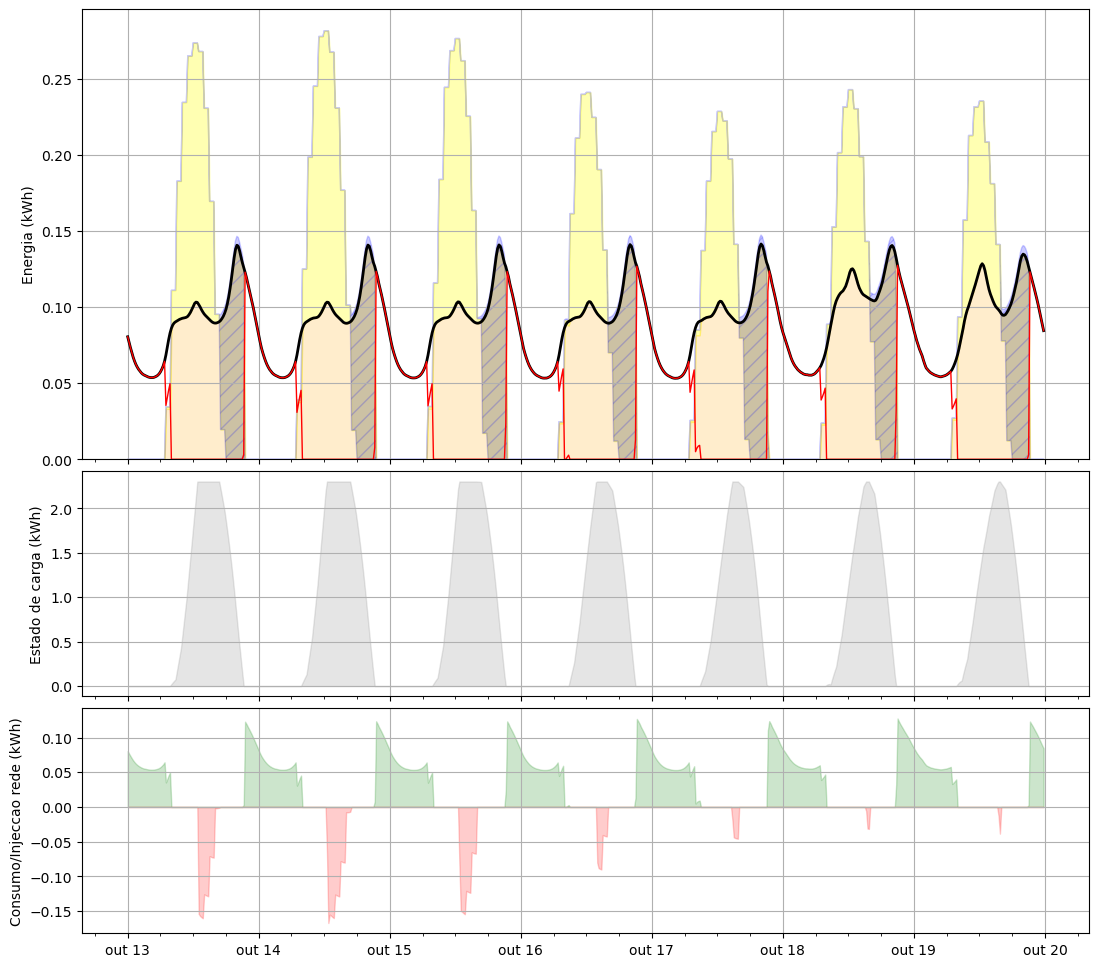

In [30]:
# plot despacho Outone
ae.plot_despacho_energia(energia, 42)

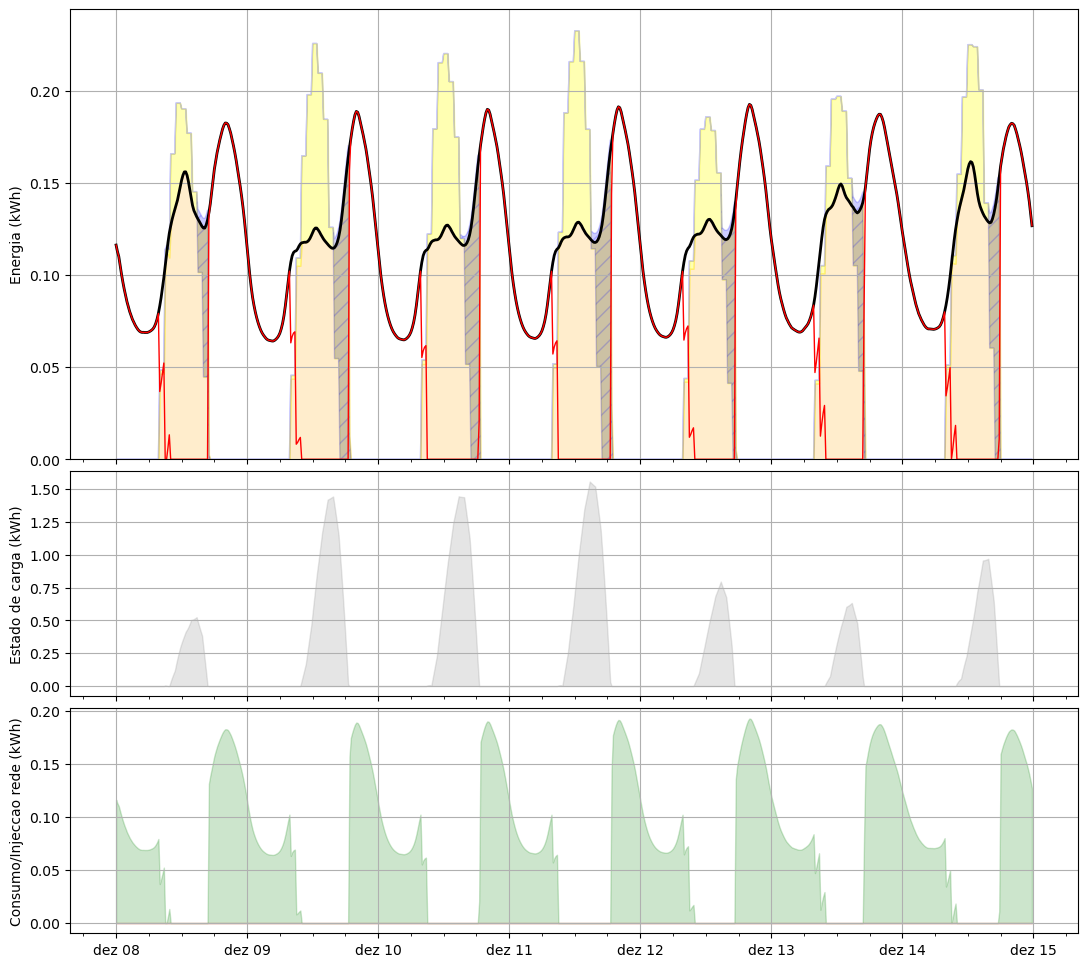

In [31]:
# plot despacho inverno
ae.plot_despacho_energia(energia, 50)

### Tarifario Indexado

In [40]:
# Sem venda à rede
recalcular = False
if os.path.exists(os.path.join(os.curdir, '15min_com_bat_sem_venda_rede_indexado_bihorario.xlsx')) and not recalcular:
    com_bat_sem_venda_rede_indexado_bihorario = pd.read_excel('15min_com_bat_sem_venda_rede_indexado_bihorario.xlsx')
else:
    params_financeiros["preco_venda_rede"] = 0.0
    com_bat_sem_venda_rede_indexado_bihorario = estudo_parametrico_custos_bateria(custos_bat, 
                                                            consumo_medio, 
                                                            producao_lisboa, 
                                                            params_sistema_com_bateria, 
                                                            params_financeiros, 
                                                            ape.TarifarioPeriodoHorario.Bihorario,
                                                            ape.TipoTarifario.Indexado)
    com_bat_sem_venda_rede_indexado_bihorario.to_excel('15min_com_bat_sem_venda_rede_indexado_bihorario.xlsx', index=False)

/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  warn('Method %s cannot handle constraints.' % method,
/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  warn('Method %s cannot handle constraints.' % method,
/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  warn('Method %s cannot handle constraints.' % method,
/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  warn('Method %s cannot handle constraints.' % method,
/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  warn('Method %s cannot handle constraints.' % method,
/opt/anaconda3/lib/python3.8/s

In [ ]:
# Com venda à rede
#custos_bat = np.arange(100, 700, 20)  
recalcular = False
if os.path.exists(os.path.join(os.curdir, '15min_com_bat_com_venda_rede_indexado_bihorario.xlsx')) and not recalcular:
    com_bat_com_venda_rede_indexado_bihorario = pd.read_excel('15min_com_bat_com_venda_rede_indexado_bihorario.xlsx')
else:
    params_financeiros["preco_venda_rede"] = preco_venda_rede
    com_bat_com_venda_rede_indexado_bihorario = estudo_parametrico_custos_bateria(custos_bat, 
                                                            consumo_medio, 
                                                            producao_lisboa, 
                                                            params_sistema_com_bateria, 
                                                            params_financeiros, 
                                                            ape.TarifarioPeriodoHorario.Bihorario,
                                                            ape.TipoTarifario.Indexado)
    com_bat_com_venda_rede_indexado_bihorario.to_excel('15min_com_bat_com_venda_rede_indexado_bihorario.xlsx', index=False)

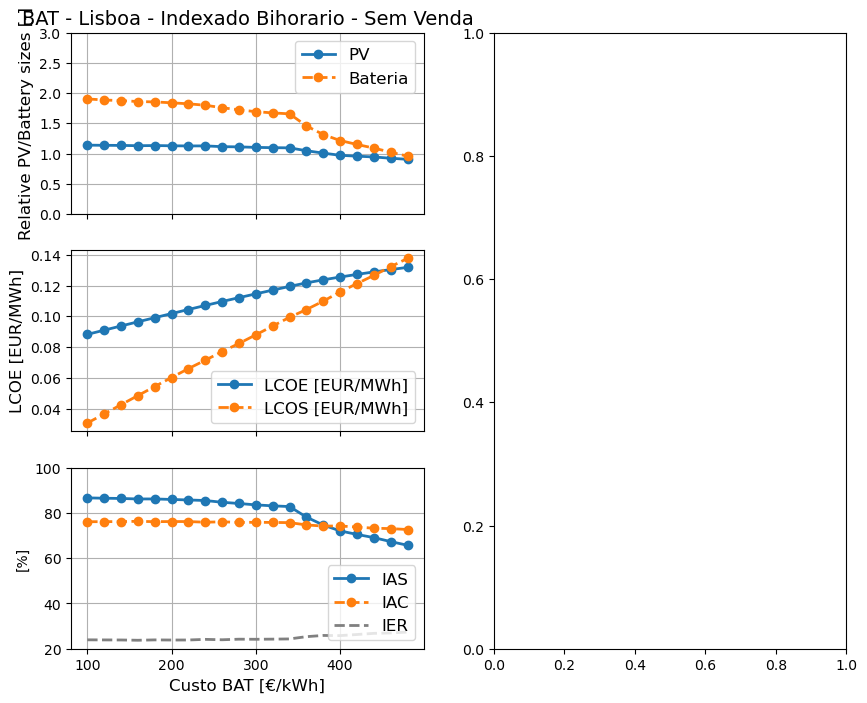

In [41]:
fig, ax = plt.subplots(1, 2, figsize=[10, 8])
plot_resultados_estudo_parametrico(ax[0], com_bat_sem_venda_rede_indexado_bihorario, 'custo_bateria', 'Custo BAT [€/kWh]', 'BAT - Lisboa - Indexado Bihorario - Sem Venda', incluir_bateria=True)
#plot_resultados_estudo_parametrico(ax[1], com_bat_com_venda_rede_indexado_bihorario, 'custo_bateria', 'Custo BAT [€/kWp]', 'BAT - Lisboa - Bihorario - Com Venda', incluir_bateria=True)
# Aqui você pode usar ax[1] para outro plot se necessário
#plt.tight_layout()
plt.show()

## Teste Sensibilidade PV+BAT

Fazer teste simples e bihorario fixando PV a 800€/kWp e 1200€/kWp.

Só experimentar com venda

#### 800€/kWp

In [34]:
params_financeiros["pv_por_kW"] = 800

# Simples
params_financeiros["preco_venda_rede"] = preco_venda_rede
sens1_com_bat_com_venda_rede_simples = estudo_parametrico_custos_bateria(custos_bat, 
                                                        consumo_medio, 
                                                        producao_lisboa, 
                                                        params_sistema_com_bateria, 
                                                        params_financeiros, 
                                                        ape.Tarifario.Simples)
sens1_com_bat_com_venda_rede_simples.to_excel('15min_pv800_com_bat_com_venda_rede_simples.xlsx', index=False)

# bihorario
sens1_com_bat_com_venda_rede_bihorario = estudo_parametrico_custos_bateria(custos_bat, 
                                                        consumo_medio, 
                                                        producao_lisboa, 
                                                        params_sistema_com_bateria, 
                                                        params_financeiros, 
                                                        ape.Tarifario.Bihorario)
sens1_com_bat_com_venda_rede_bihorario.to_excel('15min_pv800_com_bat_com_venda_rede_bihorario.xlsx', index=False)

/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  warn('Method %s cannot handle constraints.' % method,
/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  warn('Method %s cannot handle constraints.' % method,
/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  warn('Method %s cannot handle constraints.' % method,
/Users/mgfernandes/Workspace/Projectos/Solar Autoconsumo/aosol_project/src/aosol/analise/analise_energia.py:96: RuntimeWarning: invalid value encountered in double_scalars
  media_ciclos = np.sum(energia["descarga_bateria"]*intervalo)/(365*bat.capacidade_total)
/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  warn('Method %s 

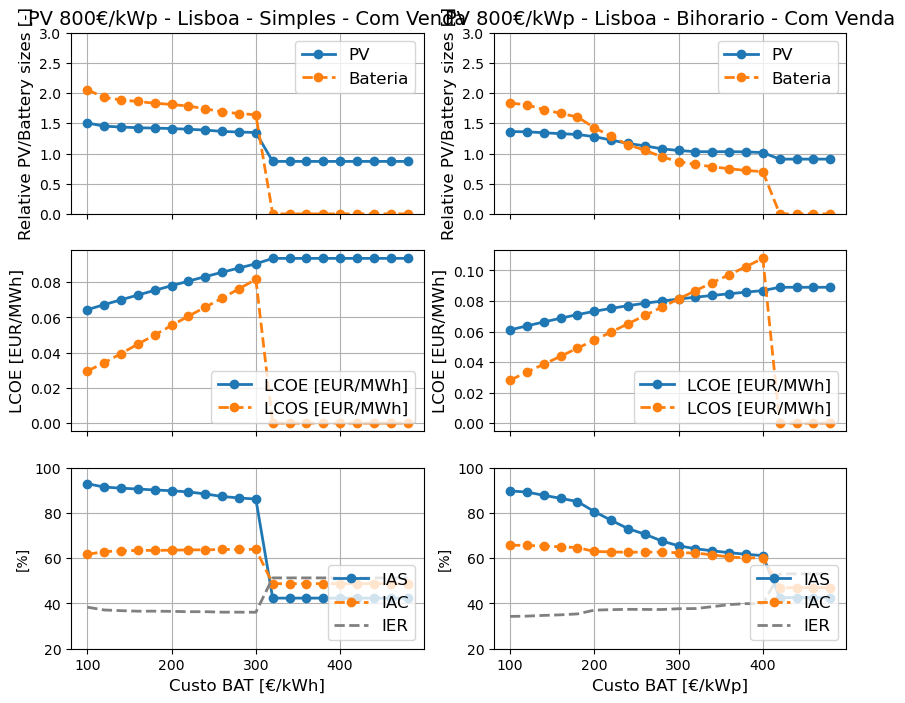

In [35]:
fig, ax = plt.subplots(1, 2, figsize=[10, 8])
plot_resultados_estudo_parametrico(ax[0], sens1_com_bat_com_venda_rede_simples, 'custo_bateria', 'Custo BAT [€/kWh]', 'PV 800€/kWp - Lisboa - Simples - Com Venda', incluir_bateria=True)
plot_resultados_estudo_parametrico(ax[1], sens1_com_bat_com_venda_rede_bihorario, 'custo_bateria', 'Custo BAT [€/kWp]', 'PV 800€/kWp - Lisboa - Bihorario - Com Venda', incluir_bateria=True)
# Aqui você pode usar ax[1] para outro plot se necessário
#plt.tight_layout()
plt.show()

#### 1200€/kWp

In [36]:
params_financeiros["pv_por_kW"] = 1200

# Simples
params_financeiros["preco_venda_rede"] = preco_venda_rede
sens2_com_bat_com_venda_rede_simples = estudo_parametrico_custos_bateria(custos_bat, 
                                                        consumo_medio, 
                                                        producao_lisboa, 
                                                        params_sistema_com_bateria, 
                                                        params_financeiros, 
                                                        ape.Tarifario.Simples)
sens2_com_bat_com_venda_rede_simples.to_excel('15min_pv1200_com_bat_com_venda_rede_simples.xlsx', index=False)

# bihorario
sens2_com_bat_com_venda_rede_bihorario = estudo_parametrico_custos_bateria(custos_bat, 
                                                        consumo_medio, 
                                                        producao_lisboa, 
                                                        params_sistema_com_bateria, 
                                                        params_financeiros, 
                                                        ape.Tarifario.Bihorario)
sens2_com_bat_com_venda_rede_bihorario.to_excel('15min_pv1200_com_bat_com_venda_rede_bihorario.xlsx', index=False)

/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  warn('Method %s cannot handle constraints.' % method,
/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  warn('Method %s cannot handle constraints.' % method,
/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  warn('Method %s cannot handle constraints.' % method,
/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  warn('Method %s cannot handle constraints.' % method,
/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  warn('Method %s cannot handle constraints.' % method,
/opt/anaconda3/lib/python3.8/s

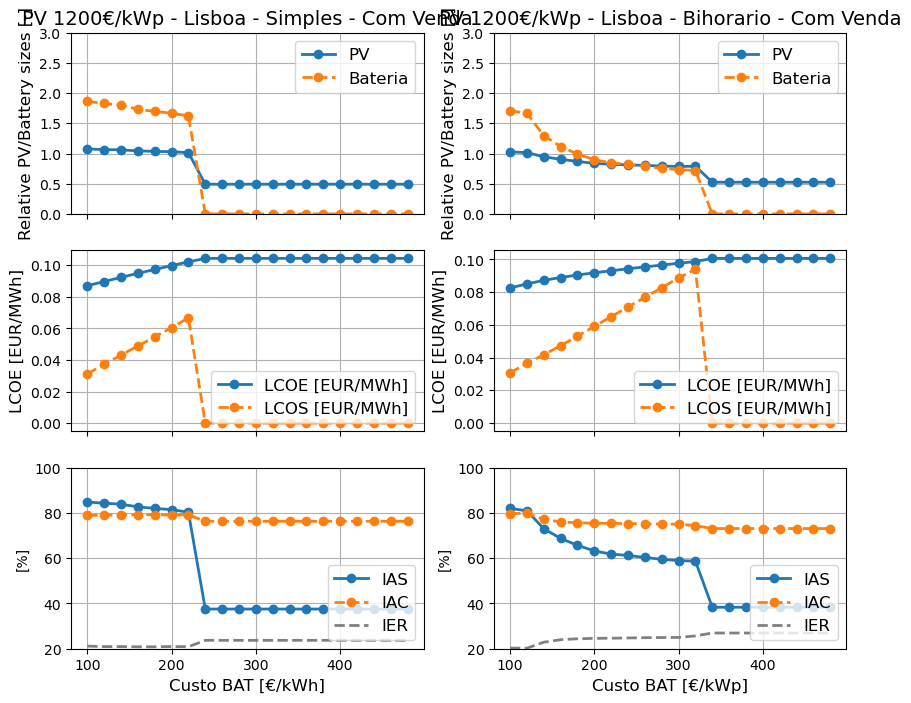

In [37]:
fig, ax = plt.subplots(1, 2, figsize=[10, 8])
plot_resultados_estudo_parametrico(ax[0], sens2_com_bat_com_venda_rede_simples, 'custo_bateria', 'Custo BAT [€/kWh]', 'PV 1200€/kWp - Lisboa - Simples - Com Venda', incluir_bateria=True)
plot_resultados_estudo_parametrico(ax[1], sens2_com_bat_com_venda_rede_bihorario, 'custo_bateria', 'Custo BAT [€/kWp]', 'PV 1200€/kWp - Lisboa - Bihorario - Com Venda', incluir_bateria=True)
# Aqui você pode usar ax[1] para outro plot se necessário
#plt.tight_layout()
plt.show()

#### Verificação

Testes de sensibilidade para verificar que o que interessa é o valor total do investimento, ou seja se mudarmos o custo instalação de 1000 para 800 e 1200€/kWp os valores totais de instalção que são rentáveis são semelhantes.

Verificamos o ultimo ponto em que deixa de ser rentável.
* Consumo 3000kWh/ano e Tarifário Simples:
    * Para 1000€/kWp: bat=260€/kWh => rpv=1.16 rbat=1.62 => 2320 + 1260 = 3580
    * Para  800€/kWp: bat=300€/kWh => rpv=1.34 rbat=1.64 => 2144 + 1476 = 3620 (delta = 40€)
    * Para 1200€/kWp: bat=220€/kWh => rpv=1.01 rbat=1.62 => 2424 + 1070 = 3490 (delta = 70€)

* Consumo 3000kWh/ano e Tarifário Bihorário:
    * Para 1000€/kWp: bat=380€/kWh => rpv=0.9 rbat=0.7 => 1800 + 800 = 2600
    * Para  800€/kWp: bat=400€/kWh => rpv=1.0 rbat=0.7 => 1600 + 840 = 2440 (delta = 160€)
    * Para 1200€/kWp: bat=320€/kWh => rpv=0.8 rbat=0.7 => 1920 + 670 = 2592 (delta = 8€)


## Optimização com bateria e re-investimento

Qual o efeito de considerar que no tempo de vida há o re-investimento numa 2a bateria

In [55]:
params_financeiros["pv_por_kW"] = 1000
params_financeiros["reinvestir_bat"] = True  # considerar 2a bateria apos tempo de vida
params_financeiros["preco_venda_rede"] = preco_venda_rede

recalcular = False

# Simples
if os.path.exists(os.path.join(os.curdir, '15min_reinvest_com_bat_com_venda_rede_simples.xlsx')) and not recalcular:
    reinvest_com_bat_com_venda_rede_simples = pd.read_excel('15min_reinvest_com_bat_com_venda_rede_simples.xlsx')
else:
    reinvest_com_bat_com_venda_rede_simples = estudo_parametrico_custos_bateria(custos_bat, 
                                                            consumo_medio, 
                                                            producao_lisboa, 
                                                            params_sistema_com_bateria, 
                                                            params_financeiros, 
                                                            ape.Tarifario.Simples)
    reinvest_com_bat_com_venda_rede_simples.to_excel('15min_reinvest_com_bat_com_venda_rede_simples.xlsx', index=False)

# bihorario
if os.path.exists(os.path.join(os.curdir, '15min_reinvest_com_bat_com_venda_rede_bihorario.xlsx')) and not recalcular:
    reinvest_com_bat_com_venda_rede_bihorario = pd.read_excel('15min_reinvest_com_bat_com_venda_rede_bihorario.xlsx')
else:
    reinvest_com_bat_com_venda_rede_bihorario = estudo_parametrico_custos_bateria(custos_bat, 
                                                        consumo_medio, 
                                                        producao_lisboa, 
                                                        params_sistema_com_bateria, 
                                                        params_financeiros, 
                                                        ape.Tarifario.Bihorario)
    reinvest_com_bat_com_venda_rede_bihorario.to_excel('15min_reinvest_com_bat_com_venda_rede_bihorario.xlsx', index=False)


/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  warn('Method %s cannot handle constraints.' % method,
/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  warn('Method %s cannot handle constraints.' % method,
/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  warn('Method %s cannot handle constraints.' % method,
/Users/mgfernandes/Workspace/Projectos/Solar Autoconsumo/aosol_project/src/aosol/analise/analise_energia.py:96: RuntimeWarning: invalid value encountered in double_scalars
  media_ciclos = np.sum(energia["descarga_bateria"]*intervalo)/(365*bat.capacidade_total)
/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  warn('Method %s 

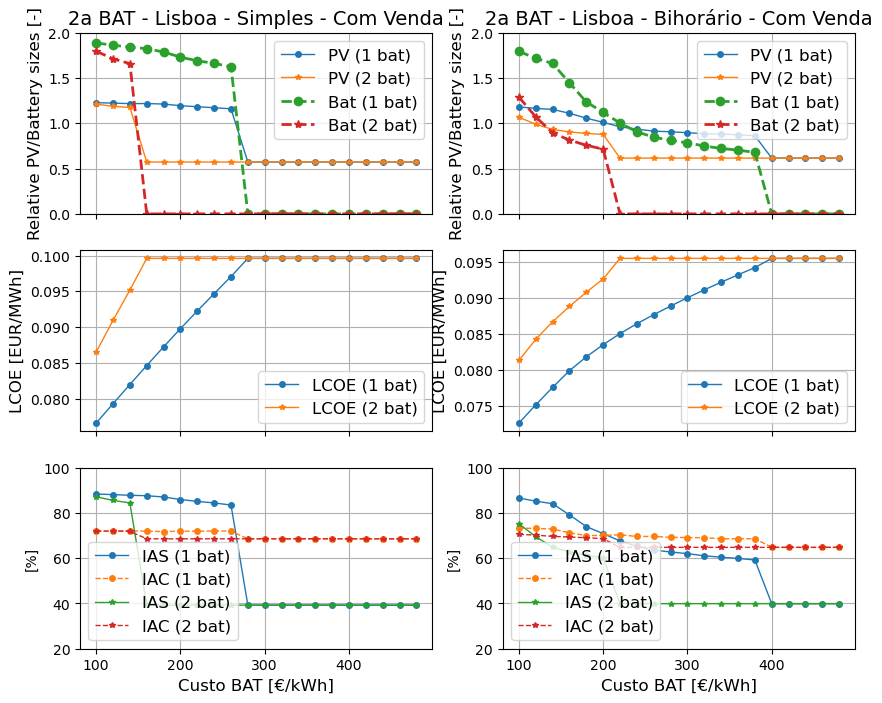

In [58]:
fig, ax = plt.subplots(1, 2, figsize=[10, 8], sharey=True)
plot_2_resultados_estudo_parametrico(ax[0], com_bat_com_venda_rede_simples, '(1 bat)', reinvest_com_bat_com_venda_rede_simples, '(2 bat)', 'custo_bateria', 'Custo BAT [€/kWh]', '2a BAT - Lisboa - Simples - Com Venda', incluir_bateria=True)
plot_2_resultados_estudo_parametrico(ax[1], com_bat_com_venda_rede_bihorario, '(1 bat)', reinvest_com_bat_com_venda_rede_bihorario, '(2 bat)', 'custo_bateria', 'Custo BAT [€/kWh]', '2a BAT - Lisboa - Bihorário - Com Venda', incluir_bateria=True)

plt.show()

Comparação custo total 1a bateria vs re-investimento, ultimo ponto em que bateria é viável.

| Caso | Tarifário | Consumo anual [kWh] | PV [€/kWp] | r_pv | Total PV [€] | Bat [€/kWh] | r_bat | Total Bat [€] | Total [€] |
| ---  | --------  | ------------------  | ---------- | ---- | ------------ | ----------- | ----- | ------------- | --------- |
| 1 bat | Simples  | 3000 | 1000 | 1,16 | 2320 | 260 | 1,62 | 1260 | 3580 |
| 2 bat | Simples  | 3000 | 1000 | 1,17 | 2340 | 140 | 1,65 | 700  | 3040 |
| 1 bat | Bihorario | 3000 | 1000 | 0,9 | 1800 | 380 | 0,7  | 800 | 2600 |
| 2 bat | Bihorario | 3000 | 1000 | 0,9 | 1800 | 200 | 0,7  | 420 | 2220 |

Mesmas dimensões mas preços mais baixos, requerem redução do investimento inicial de 400€ para depois se investir numa 2a bateria

## Variar PV+BAT

In [38]:
# Sem venda à rede
# if os.path.exists(os.path.join(os.curdir, 'temp_com_bat_sem_venda_rede_simples.xlsx')):
#     com_bat_sem_venda_rede_simples = pd.read_excel('temp_com_bat_sem_venda_rede_simples.xlsx')
# else:
#     params_financeiros["preco_venda_rede"] = 0.0
#     com_bat_sem_venda_rede_simples = estudo_parametrico_custos_pv_bateria(custos_pv, 
#                                                                             custos_bat,
#                                                                             consumo_medio, 
#                                                                             producao_lisboa, 
#                                                                             params_sistema_com_bateria, 
#                                                                             params_financeiros, 
#                                                                             ape.Tarifario.Simples)
#     com_bat_sem_venda_rede_simples.to_excel('temp_com_bat_sem_venda_rede_simples.xlsx', index=False)


In [39]:
# fig, ax = plt.subplots(2, 2, figsize=(12, 12), sharey=True, sharex=True)

# x = np.array(com_bat_sem_venda_rede_simples["custo_pv"].unique())
# y = np.array(com_bat_sem_venda_rede_simples["custo_bateria"].unique())
# X, Y = np.meshgrid(x, y)

# LCOE = com_bat_sem_venda_rede_simples["LCOE"].values.reshape(len(y), len(x))
# R_PV = com_bat_sem_venda_rede_simples["r_pv"].values.reshape(len(y), len(x))
# R_BAT = com_bat_sem_venda_rede_simples["r_bat"].values.reshape(len(y), len(x))
# IAC = com_bat_sem_venda_rede_simples["iac"].values.reshape(len(y), len(x))
# IAS = com_bat_sem_venda_rede_simples["ias"].values.reshape(len(y), len(x))

# import matplotlib
# import matplotlib.cm as cm
# matplotlib.rcParams['xtick.direction'] = 'out'
# matplotlib.rcParams['ytick.direction'] = 'out'

# levels = np.arange(0.05,0.30,0.01)
# levels_ias = np.arange(30, 100, 5)
# levels_rpv = np.arange(0.2, 2.0, 0.2)
# levels_rbat = np.arange(0.2, 3.0, 0.2)

# #CS1 = ax.contour(PV, BAT, IAS, colors='black', linewidths=1., linestyles='--', levels=levels_ias)
# CS1 = ax[0,0].contour(X, Y, LCOE, colors='black', linewidths=1.,levels=levels)
# CS1s = ax[0,0].contourf(X, Y, LCOE, cmap=cm.Purples, alpha=1,levels=levels)
# ax[0,0].grid()
# ax[0,0].clabel(CS1, inline=1, fontsize=10)
# #ax[0,0].xlabel('PV [€/kWp]')
# ax[0,0].set_ylabel('BATERIA [€/kWh]')
# ax[0,0].set_title('LCOE [€/kWh]')
# #ax.clabel(CS1, inline=1, fontsize=10)

# CS2 = ax[0,1].contour(X, Y, R_PV, colors='black', linewidths=1., levels=levels_rpv)
# CS2s = ax[0,1].contourf(X, Y, R_PV, cmap=cm.Purples, alpha=1, levels=levels_rpv)
# ax[0,1].grid()
# ax[0,1].clabel(CS2, inline=1, fontsize=10)
# ax[0,1].set_title('R_PV [-]')

# CS3 = ax[1,0].contour(X, Y, R_BAT, colors='black', linewidths=1., levels=levels_rbat)
# CS3s = ax[1,0].contourf(X, Y, R_BAT, cmap=cm.Purples, alpha=1, levels=levels_rbat)
# ax[1,0].grid()
# ax[1,0].clabel(CS3, inline=1, fontsize=10)
# ax[1,0].set_xlabel('PV [€/kWp]')
# ax[1,0].set_ylabel('BATERIA [€/kWh]')
# ax[1,0].set_title('R_BAT [-]')

# CS4 = ax[1,1].contour(X, Y, IAS, colors='black', linewidths=1., levels=levels_ias)
# CS4s = ax[1,1].contourf(X, Y, IAS, cmap=cm.Purples, alpha=1, levels=levels_ias)
# ax[1,1].grid()
# ax[1,1].clabel(CS4, inline=1, fontsize=10)
# ax[1,1].set_xlabel('PV [€/kWp]')
# ax[1,1].set_title('IAS [%]')